## STUDENT DETAILS
TAKUNDA JAMES ZINHONDO
R234850F
HACS409
ASSIGNMENT 1

## ASSUMPTIONS

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

S0 = 100
K = 100
r = 0.05
T = 3/12
sigma = 0.20

## Question 1:

Put-call parity is applicable to European call and put options when both contracts are based on the same underlying asset and have identical strike prices and expiration dates. For an underlying asset that does not pay dividends, the put-call parity relationship is expressed as:

$$
C - P = S_0 - Ke^{-rT}
$$

The relationship may also be represented in the following equivalent form:

$$
C + Ke^{-rT} = P + S_0
$$

where \(C\) denotes the price of the European call option, \(P\) represents the price of the European put option, \(S_0\) is the current price of the underlying asset, \(K\) is the option's strike price, \(r\) represents the risk-free interest rate, and \(T\) denotes the time remaining until maturity.

The validity of put-call parity is based on the **no-arbitrage principle**. A portfolio comprising a European call option together with the present value of the strike price generates the same payoff at maturity as a portfolio consisting of a European put option and the underlying asset. Because both portfolios provide identical future payoffs, their values must be equal at the present time. If their current values differed, investors could construct an arbitrage strategy that generates a risk-free profit.


## Question 2:

For European options, the put-call parity relationship can be expressed as:

$$
C + Ke^{-rT} = P + S_0
$$

### (a) Determining the Call Price

Rearranging the put-call parity equation to make \(C\) the subject gives:

$$
\boxed{C = P + S_0 - Ke^{-rT}}
$$

Thus, the value of a European call option can be determined using the price of the equivalent European put option, the current price of the underlying asset, and the present value of the strike price.

### (b) Determining the Put Price

Similarly, rearranging the relationship to make \(P\) the subject results in:

$$
\boxed{P = C - S_0 + Ke^{-rT}}
$$

Hence, the price of a European put option can be calculated from the corresponding European call price, the current underlying asset price, and the discounted value of the strike price.


## Question 3:

The conventional put-call parity relationship does not normally hold as an exact equality for American options. This is because, unlike European options, which may only be exercised at maturity, American options can be exercised at any point before or at the expiration date. The possibility of early exercise can therefore influence the relationship between the values of the corresponding call and put options.

For a non-dividend-paying stock, an American call option will generally have the same value as its European counterpart since exercising the call before maturity is typically not optimal. In contrast, an American put option may be worth more than an equivalent European put because the holder has the additional benefit of being able to exercise the option before expiration.

Consequently, rather than satisfying the exact European put-call parity condition,

$$
C - P = S_0 - Ke^{-rT},
$$

American options generally satisfy the following inequality bounds:

$$
S_0-K \leq C_A-P_A \leq S_0-Ke^{-rT}.
$$

These bounds arise from the additional flexibility associated with early exercise. This feature provides American options with greater optionality, particularly in the case of put options. Therefore, the exact put-call parity relationship applicable to European options cannot generally be applied to American options.


## Question 4
a) Pricing ATM European Call and Put Using a Binomial Tree

The at-the-money (ATM) European call and put options are valued using the Cox-Ross-Rubinstein (CRR) binomial tree model. The analysis is based on the following parameters:

* Initial stock price: \(S_0 = 100\)
* Strike price: \(K = 100\)
* Risk-free interest rate: \(r = 5\%\)
* Time to maturity: \(T = 0.25\) years
* Volatility: \(\sigma = 20\%\)

To obtain stable and accurate option price estimates, the binomial model is implemented using \(N = 200\) time steps. Increasing the number of steps improves the approximation of the continuous-time option pricing process. Therefore, 200 steps provide a suitable compromise between computational efficiency and numerical precision.


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Base case parameters
S0 = 100
K = 100
r = 0.05
T = 3 / 12
sigma = 0.20

# Number of binomial steps
N = 200

# Length of each time step
dt = T / N

# CRR binomial tree parameters
u = np.exp(sigma * np.sqrt(dt))
d = 1 / u

# Risk-neutral probability
p = (np.exp(r * dt) - d) / (u - d)

# Discount factor
discount = np.exp(-r * dt)

print(f"Number of steps: {N}")
print(f"Time step: {dt:.6f}")
print(f"Up factor (u): {u:.6f}")
print(f"Down factor (d): {d:.6f}")
print(f"Risk-neutral probability (p): {p:.6f}")

Number of steps: 200
Time step: 0.001250
Up factor (u): 1.007096
Down factor (d): 0.992954
Risk-neutral probability (p): 0.502652


In [5]:
def european_binomial_option(S0, K, r, T, sigma, N, option_type="call"):

    # Time step
    dt = T / N

    # Up and down factors
    u = np.exp(sigma * np.sqrt(dt))
    d = 1 / u

    # Risk-neutral probability
    p = (np.exp(r * dt) - d) / (u - d)

    # Discount factor
    discount = np.exp(-r * dt)

    # Stock prices at maturity
    j = np.arange(N + 1)
    ST = S0 * (u ** j) * (d ** (N - j))

    # Option payoff at maturity
    if option_type == "call":
        option_values = np.maximum(ST - K, 0)
    elif option_type == "put":
        option_values = np.maximum(K - ST, 0)

    # Backward induction
    for i in range(N, 0, -1):
        option_values = discount * (
            p * option_values[1:i+1] +
            (1 - p) * option_values[0:i]
        )

    return option_values[0]

In [ ]:
# Calculate European call price
european_call = european_binomial_option(
    S0, K, r, T, sigma, N, "call"
)

# Calculate European put price
european_put = european_binomial_option(
    S0, K, r, T, sigma, N, "put"
)

# Display results in a table
results_q4 = pd.DataFrame({
    "Option": ["European Call", "European Put"],
    "Price": [round(european_call, 2), round(european_put, 2)]
})

results_q4

,Option,Price
0,European Call,4.61
1,European Put,3.36


*b) Interpretation*

Using the 200-step Cox-Ross-Rubinstein (CRR) binomial tree, the estimated prices of the at-the-money (ATM) European call and put options are presented in the table above.

The European call option has a greater value than the corresponding put option. This difference arises because the positive risk-free interest rate causes the current stock price to be greater than the present value of the strike price.

The choice of 200 time steps provides a sufficiently detailed approximation of the underlying asset's continuous-time price evolution while maintaining reasonable computational efficiency. Although using a larger number of steps could further improve the convergence of the binomial model, the resulting changes in the estimated option prices would generally become progressively smaller.




## Question 5

In [ ]:
def european_binomial_delta(S0, K, r, T, sigma, N, option_type="call"):

    dt = T / N

    # Up and down factors
    u = np.exp(sigma * np.sqrt(dt))
    d = 1 / u

    # Risk-neutral probability
    p = (np.exp(r * dt) - d) / (u - d)
    discount = np.exp(-r * dt)

    # Stock prices at maturity
    j = np.arange(N + 1)
    ST = S0 * (u ** j) * (d ** (N - j))

    # Option payoffs at maturity
    if option_type == "call":
        option_values = np.maximum(ST - K, 0)
    else:
        option_values = np.maximum(K - ST, 0)

    # Work backwards until time step 1
    for i in range(N, 1, -1):
        option_values = discount * (
            p * option_values[1:i+1] +
            (1 - p) * option_values[0:i]
        )

    # Option values after an up and down movement
    V_down = option_values[0]
    V_up = option_values[1]

    # Stock prices after one step
    S_down = S0 * d
    S_up = S0 * u

    # Delta at time 0
    delta = (V_up - V_down) / (S_up - S_down)

    return delta

In [ ]:
# Calculate Delta for the European call
call_delta = european_binomial_delta(
    S0, K, r, T, sigma, N, "call"
)

# Calculate Delta for the European put
put_delta = european_binomial_delta(
    S0, K, r, T, sigma, N, "put"
)

# Display results
results_q5 = pd.DataFrame({
    "Option": ["European Call", "European Put"],
    "Delta": [round(call_delta, 4), round(put_delta, 4)]
})

results_q5

,Option,Delta
0,European Call,0.5693
1,European Put,-0.4307


 Delta for the European Call and Put

Delta is a measure of an option’s sensitivity to changes in the price of the underlying asset. It indicates the approximate change in the option’s value resulting from a one-unit increase in the underlying asset price.

Based on the binomial tree analysis, the European call option has a positive Delta, whereas the European put option has a negative Delta. The call Delta is approximately \(0.5693\), indicating that a one-unit increase in the stock price is expected to increase the value of the call option by about \(0.5693\) units. Conversely, the put Delta is approximately \(-0.4307\), implying that a one-unit increase in the stock price is expected to reduce the value of the put option by approximately \(0.4307\) units.

The signs of these Delta values reflect the fundamental characteristics of the two option types. A call option gains value as the underlying asset price rises and therefore exhibits a positive Delta. In contrast, a put option increases in value when the underlying asset price falls, resulting in a negative Delta.

Consequently, Delta serves as an important indicator of the responsiveness of an option’s price to movements in the underlying asset. Furthermore, the difference between the call and put Deltas is close to one, which is consistent with the theoretical relationship implied by put-call parity.


## Question 6:

To assess Vega, the European call and put options are revalued after increasing the volatility of the underlying asset from \(20\%\) to \(25\%\). Vega represents the sensitivity of an option’s value to changes in the volatility of the underlying asset.

The resulting change in the option price is determined using:

$$
\text{Change in Price}
=
V_{\sigma=25\%}-V_{\sigma=20\%}
$$

where \(V_{\sigma=25\%}\) represents the option value when volatility is \(25\%\), while \(V_{\sigma=20\%}\) denotes the initial option value when volatility is \(20\%\).


In [ ]:
# New volatility
sigma_new = 0.25

# Re-price the European call and put at 25% volatility
call_price_25 = european_binomial_option(
    S0, K, r, T, sigma_new, N, "call"
)

put_price_25 = european_binomial_option(
    S0, K, r, T, sigma_new, N, "put"
)

# Calculate the changes in option prices
call_change = call_price_25 - european_call
put_change = put_price_25 - european_put

# Create results table
results_q6 = pd.DataFrame({
    "Option": ["European Call", "European Put"],
    "Price at 20% Volatility": [
        round(european_call, 2),
        round(european_put, 2)
    ],
    "Price at 25% Volatility": [
        round(call_price_25, 2),
        round(put_price_25, 2)
    ],
    "Increase in Price": [
        round(call_change, 2),
        round(put_change, 2)
    ]
})

results_q6

,Option,Price at 20% Volatility,Price at 25% Volatility,Increase in Price
0,European Call,4.61,5.59,0.98
1,European Put,3.36,4.34,0.98


***Results and Interpretation***

The results indicate that raising the volatility of the underlying asset from \(20\%\) to \(25\%\) increases the values of both the European call and put options. This is because greater volatility creates more uncertainty about future movements in the underlying asset price, increasing the possibility of favourable outcomes for the option holder while limiting the maximum potential loss to the option premium.

The European call price increases from approximately \(4.61\) to \(5.59\), while the European put price rises from approximately \(3.36\) to \(4.34\). Consequently, both options record an increase of approximately \(0.98\).

The magnitude of the price change is approximately identical for the call and put options. This is consistent with the theoretical result that European call and put options with the same underlying asset, strike price, and maturity have equal Vega. Since volatility is not explicitly included in the put-call parity equation, changes in volatility result in equal theoretical changes in the prices of the corresponding European call and put options.


## Question 7:

The at-the-money (ATM) American call and put options are valued using the Cox-Ross-Rubinstein (CRR) binomial tree model. The analysis uses the following base-case parameters:

* Initial stock price: \(S_0 = 100\)
* Strike price: \(K = 100\)
* Risk-free interest rate: \(r = 5\%\)
* Time to maturity: \(T = 0.25\) years
* Volatility: \(\sigma = 20\%\)

The binomial tree is constructed using \(N = 200\) time steps, providing a reliable approximation of the option values while maintaining computational efficiency.

Unlike European options, American options can be exercised at any point before or at maturity. Consequently, at each node of the binomial tree, the option's continuation value is compared with its immediate exercise value. The greater of these two values is then used as the option value at that node, thereby incorporating the possibility of optimal early exercise into the valuation process.



In [ ]:
# Question 7: American option pricing using a binomial tree

def american_binomial_option(S0, K, r, T, sigma, N, option_type):

    # Step 1: Calculate the length of each time step
    dt = T / N

    # Step 2: Calculate the up and down factors
    u = np.exp(sigma * np.sqrt(dt))
    d = 1 / u

    # Step 3: Calculate the risk-neutral probability
    p = (np.exp(r * dt) - d) / (u - d)

    # Step 4: Calculate the discount factor
    discount = np.exp(-r * dt)

    # Step 5: Calculate stock prices at maturity
    j = np.arange(N + 1)
    stock_prices = S0 * (u ** j) * (d ** (N - j))

    # Step 6: Calculate option payoffs at maturity
    if option_type == "call":
        option_values = np.maximum(stock_prices - K, 0)
    else:
        option_values = np.maximum(K - stock_prices, 0)

    # Step 7: Work backwards through the tree
    for i in range(N - 1, -1, -1):

        # Calculate continuation value
        continuation_value = discount * (
            p * option_values[1:i+2]
            + (1 - p) * option_values[0:i+1]
        )

        # Calculate stock prices at the current node
        j = np.arange(i + 1)
        stock_prices = S0 * (u ** j) * (d ** (i - j))

        # Calculate immediate exercise value
        if option_type == "call":
            exercise_value = np.maximum(stock_prices - K, 0)
        else:
            exercise_value = np.maximum(K - stock_prices, 0)

        # American option: choose the maximum value
        option_values = np.maximum(
            continuation_value,
            exercise_value
        )

    return option_values[0]


# Calculate the American call price
american_call = american_binomial_option(
    S0, K, r, T, sigma, N, "call"
)

# Calculate the American put price
american_put = american_binomial_option(
    S0, K, r, T, sigma, N, "put"
)


# Display results in a table
results_q7 = pd.DataFrame({
    "Option": ["American Call", "American Put"],
    "Price": [
        round(american_call, 2),
        round(american_put, 2)
    ]
})

results_q7

,Option,Price
0,American Call,4.61
1,American Put,3.47


*Interpretation*

The at-the-money (ATM) American call and put options were valued using a 200-step Cox-Ross-Rubinstein (CRR) binomial tree.

The value of the American call is expected to be approximately equal to that of the corresponding European call because the underlying asset is assumed to pay no dividends. Under these circumstances, exercising the American call before maturity is generally suboptimal, meaning that the early-exercise feature does not provide significant additional value.

In contrast, the American put may be more valuable than its European counterpart because the holder has the flexibility to exercise the option before the expiration date. This additional early-exercise opportunity can increase the value of the American put.

The binomial tree model accounts for this feature by evaluating both the continuation value and the immediate exercise value at each node. The higher of the two values is selected as the option value at that node. Using \(N = 200\) time steps provides a sufficiently accurate approximation of the option prices while maintaining reasonable computational efficiency.


## Question 8:

The Delta of the at-the-money (ATM) American call and put options is determined at time 0 using the binomial tree model. Delta measures the sensitivity of an option’s value to changes in the price of the underlying stock.

Within the binomial tree framework, Delta is calculated using the following expression:

$$
\Delta = \frac{V_u - V_d}{S_u - S_d}
$$

where \(V_u\) and \(V_d\) represent the option values following an upward and downward movement in the binomial tree, respectively, while \(S_u\) and \(S_d\) denote the corresponding stock prices.

The resulting Deltas for the American call and put options are subsequently compared with the European option Deltas obtained in Question 5.


In [ ]:
# Question 8: Calculate Delta for American call and put

def american_binomial_delta(S0, K, r, T, sigma, N, option_type):

    # Time step
    dt = T / N

    # Up and down factors
    u = np.exp(sigma * np.sqrt(dt))
    d = 1 / u

    # Risk-neutral probability
    p = (np.exp(r * dt) - d) / (u - d)

    # Discount factor
    discount = np.exp(-r * dt)

    # Stock prices at maturity
    j = np.arange(N + 1)
    stock_prices = S0 * (u ** j) * (d ** (N - j))

    # Option payoff at maturity
    if option_type == "call":
        option_values = np.maximum(stock_prices - K, 0)
    else:
        option_values = np.maximum(K - stock_prices, 0)

    # Work backwards until time 1
    for i in range(N - 1, 0, -1):

        # Continuation value
        continuation_value = discount * (
            p * option_values[1:i+2]
            + (1 - p) * option_values[0:i+1]
        )

        # Stock prices at the current step
        j = np.arange(i + 1)
        stock_prices = S0 * (u ** j) * (d ** (i - j))

        # Immediate exercise value
        if option_type == "call":
            exercise_value = np.maximum(stock_prices - K, 0)
        else:
            exercise_value = np.maximum(K - stock_prices, 0)

        # American option value
        option_values = np.maximum(
            continuation_value,
            exercise_value
        )

    # Option values after one up and one down movement
    V_down = option_values[0]
    V_up = option_values[1]

    # Stock prices after one down and one up movement
    S_down = S0 * d
    S_up = S0 * u

    # Calculate Delta
    delta = (V_up - V_down) / (S_up - S_down)

    return delta


# Calculate American call Delta
american_call_delta = american_binomial_delta(
    S0, K, r, T, sigma, N, "call"
)

# Calculate American put Delta
american_put_delta = american_binomial_delta(
    S0, K, r, T, sigma, N, "put"
)


# Display the results
results_q8 = pd.DataFrame({
    "Option": ["American Call", "American Put"],
    "Delta": [
        round(american_call_delta, 4),
        round(american_put_delta, 4)
    ]
})

results_q8

,Option,Delta
0,American Call,0.5693
1,American Put,-0.4498


Results and Interpretation

The American call option has a positive Delta of approximately \(0.5693\), whereas the American put option has a negative Delta of approximately \(-0.4498\).

The positive Delta of the call indicates that a one-unit increase in the underlying stock price results in an approximate \(0.5693\)-unit increase in the value of the American call. Conversely, the negative Delta of the put implies that a one-unit increase in the stock price leads to an approximate \(0.4498\)-unit reduction in the value of the American put.

The Delta of the American call is approximately equal to that of the corresponding European call. This is consistent with the fact that early exercise is generally not optimal for a call option written on a non-dividend-paying stock. In contrast, the Delta of the American put differs from that of the European put because the ability to exercise before maturity influences the option's sensitivity to changes in the underlying stock price.


## Question 9:

Five different strike prices are considered to capture a range of option moneyness:

* \(K = 90\)
* \(K = 95\)
* \(K = 100\)
* \(K = 105\)
* \(K = 110\)

Given that the initial stock price is \(S_0 = 100\), these strike prices represent varying degrees of moneyness, ranging from in-the-money to out-of-the-money positions for the European call option.

A trinomial tree model is employed to value the corresponding European call and put options for each of the selected strike prices.


In [ ]:
# Question 9: European call and put pricing using a trinomial tree

def european_trinomial_option(S0, K, r, T, sigma, N, option_type):

    dt = T / N

    # Trinomial tree movement factors
    u = np.exp(sigma * np.sqrt(3 * dt))
    d = 1 / u

    # Risk-neutral probabilities
    pu = 1/6 + ((r - 0.5 * sigma**2) * np.sqrt(dt)) / (2 * sigma * np.sqrt(3))
    pm = 2/3
    pd = 1/6 - ((r - 0.5 * sigma**2) * np.sqrt(dt)) / (2 * sigma * np.sqrt(3))

    discount = np.exp(-r * dt)

    # Terminal stock prices
    j = np.arange(-N, N + 1)
    stock_prices = S0 * (u ** j)

    # Terminal option payoffs
    if option_type == "call":
        option_values = np.maximum(stock_prices - K, 0)
    else:
        option_values = np.maximum(K - stock_prices, 0)

    # Work backwards through the tree
    for i in range(N, 0, -1):

        option_values = discount * (
            pu * option_values[2:2*i+1]
            + pm * option_values[1:2*i]
            + pd * option_values[0:2*i-1]
        )

    return option_values[0]


# Use the same number of steps
N_tri = 200

# Five strike prices
strikes = [90, 95, 100, 105, 110]

call_prices = []
put_prices = []

# Calculate call and put prices
for strike in strikes:

    call = european_trinomial_option(
        S0, strike, r, T, sigma, N_tri, "call"
    )

    put = european_trinomial_option(
        S0, strike, r, T, sigma, N_tri, "put"
    )

    call_prices.append(round(call, 2))
    put_prices.append(round(put, 2))


# Display results in a table
results_q9 = pd.DataFrame({
    "Strike Price": strikes,
    "Moneyness (K/S0)": [round(K/S0, 2) for K in strikes],
    "European Call": call_prices,
    "European Put": put_prices
})

results_q9

,Strike Price,Moneyness (K/S0),European Call,European Put
0,90,0.90,11.67,0.55
1,95,0.95,7.71,1.53
2,100,1.00,4.61,3.36
3,105,1.05,2.48,6.17
4,110,1.10,1.19,9.83


Results and Interpretation

The results demonstrate a clear relationship between option values and their respective levels of moneyness.

As the strike price increases, the value of the European call option declines. This is because a higher strike price reduces the likelihood that the option will be in the money at maturity, thereby lowering its value.

Conversely, the value of the European put option increases as the strike price rises. A higher strike price gives the put holder the right to sell the underlying asset at a more favourable price, increasing the potential payoff from the option.

Thus, lower strike prices make call options more valuable because they place the options further in the money. In contrast, higher strike prices increase the value of put options by providing greater protection against declines in the underlying stock price.

Overall, the observed pricing patterns are consistent with established option pricing theory and are economically intuitive.


## Question 10(a):

For European options, the put-call parity relationship is expressed as:

$$
C-P=S_0-Ke^{-rT}
$$

where:

* \(C\) represents the European call option price.
* \(P\) represents the European put option price.
* \(S_0\) denotes the initial price of the underlying stock.
* \(K\) is the strike price.
* \(r\) represents the risk-free interest rate.
* \(T\) denotes the time remaining until maturity.

The put-call parity condition is initially evaluated using the at-the-money (ATM) strike price. It is then tested across all five strike prices considered in Question 9 to determine whether the relationship remains consistent for different levels of moneyness.


In [ ]:
# Question 10(a): Check put-call parity across all five strikes

# Calculate the left-hand and right-hand sides of put-call parity
parity_results = pd.DataFrame({
    "Strike": strikes,
    "Call Price": call_prices,
    "Put Price": put_prices
})

# Left-hand side: C - P
parity_results["C - P"] = (
    parity_results["Call Price"] -
    parity_results["Put Price"]
)

# Right-hand side: S0 - K*exp(-rT)
parity_results["S0 - K*exp(-rT)"] = [
    S0 - K_value * np.exp(-r * T)
    for K_value in strikes
]

# Difference between both sides
parity_results["Difference"] = (
    parity_results["C - P"] -
    parity_results["S0 - K*exp(-rT)"]
)

# Round results
parity_results = parity_results.round(4)

parity_results

,Strike,Call Price,Put Price,C - P,S0 - K*exp(-rT),Difference
0,90,11.67,0.55,11.12,11.1180,0.0020
1,95,7.71,1.53,6.18,6.1801,-0.0001
2,100,4.61,3.36,1.25,1.2422,0.0078
3,105,2.48,6.17,-3.69,-3.6957,0.0057
4,110,1.19,9.83,-8.64,-8.6336,-0.0064


Results and Interpretation

The results demonstrate that the European call and put option prices satisfy the put-call parity relationship across all five strike prices, subject only to minor numerical rounding differences.

For each strike price, the calculated difference between the call and put prices, \(C-P\), is approximately equal to:

$$
S_0-Ke^{-rT}
$$

Any small discrepancies observed can be attributed to numerical approximation and rounding arising from the trinomial tree valuation.

The validity of put-call parity follows from the no-arbitrage principle. A portfolio comprising a European call option and cash equivalent to the present value of the strike price generates the same payoff at maturity as a portfolio consisting of a European put option and the underlying stock. Under the assumptions of no arbitrage and European-style exercise, portfolios that produce identical payoffs at maturity must have equal values at time 0.

Therefore, the results provide a useful consistency check for the European call and put prices calculated using the trinomial tree in Question 9.


## Question 10(b):

The European and American option prices obtained in the previous questions are compared to determine the effect of the early-exercise feature available to American options.

In [ ]:
# Question 10(b): Compare European and American option prices

comparison_q10 = pd.DataFrame({
    "Option": [
        "European Call",
        "American Call",
        "European Put",
        "American Put"
    ],

    "Price": [
        european_call,
        american_call,
        european_put,
        american_put
    ]
})

# Round the results
comparison_q10 = comparison_q10.round(4)

comparison_q10

,Option,Price
0,European Call,4.6050
1,American Call,4.6050
2,European Put,3.3628
3,American Put,3.4746


Results and Interpretation

The American call option has a value that is approximately equal to that of the corresponding European call. This outcome is consistent with theoretical expectations because the underlying asset is assumed to pay no dividends. Under such conditions, exercising an American call before its maturity date is generally not optimal.

In contrast, the American put option has a higher value than the equivalent European put. This difference arises from the additional flexibility available to the holder of an American put, who can exercise the option at any time up to and including maturity.

Consequently, the early-exercise feature provides little or no additional value to the call option under the assumptions of the model, whereas it can increase the value of the put option. These findings are consistent with the theoretical principle that an American option should have a value at least as high as that of its corresponding European option.


## Question 10(c):

The relationship between European option prices and strike prices is illustrated graphically using the five strike prices from Question 9.

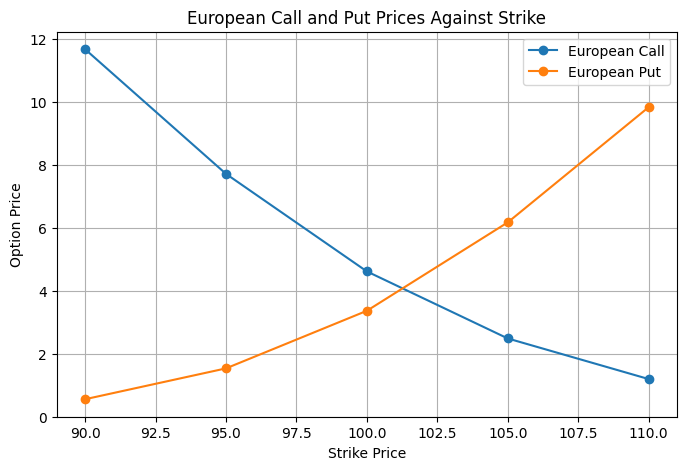

In [ ]:
# Question 10(c): Graph option prices against strike

plt.figure(figsize=(8, 5))

plt.plot(
    strikes,
    call_prices,
    marker="o",
    label="European Call"
)

plt.plot(
    strikes,
    put_prices,
    marker="o",
    label="European Put"
)

plt.xlabel("Strike Price")
plt.ylabel("Option Price")
plt.title("European Call and Put Prices Against Strike")
plt.legend()
plt.grid(True)

plt.show()

The graph indicates that European call option prices decline as the strike price increases. This is because a higher strike price reduces the likelihood of the call finishing in-the-money, thereby lowering its value.

In contrast, European put option prices increase as the strike price rises. A higher strike price provides the put holder with a more favourable price at which to sell the underlying asset, increasing the option’s value.

Overall, the graph confirms the negative relationship between strike price and call option value, and the positive relationship between strike price and put option value.


## Question 11:

The Heston stochastic-volatility model is used to price an ATM European call and put using Monte Carlo simulation.

The base-case parameters remain:

- Initial stock price, S0 = 100
- Strike price, K = 100
- Risk-free interest rate, r = 5%
- Time to maturity, T = 0.25 years

The Heston model parameters are:

- Initial variance, v0 = 0.04
- Mean reversion speed, κ = 1.85
- Long-run variance, θ = 0.04
- Volatility of volatility, ξ = 0.35

Since v0 = θ = 0.04, the corresponding long-run volatility is 20%, making the results comparable with the constant-volatility baseline.

The options are priced twice using correlation values of ρ = -0.30 and ρ = -0.70.

In [ ]:
# Question 11: Heston model using Monte Carlo simulation

import numpy as np
import pandas as pd

def heston_option_price(S0, K, r, T, v0, kappa, theta,
                        xi, rho, n_simulations=50000, n_steps = 200):

    dt = T / n_steps

    # Initial stock prices and variances
    S = np.full(n_simulations, S0, dtype=float)
    v = np.full(n_simulations, v0, dtype=float)

    # Monte Carlo simulation
    for i in range(n_steps):

        # Generate two correlated random variables
        Z1 = np.random.normal(size=n_simulations)
        Z2 = np.random.normal(size=n_simulations)

        W1 = Z1
        W2 = rho * Z1 + np.sqrt(1 - rho**2) * Z2

        # Ensure variance remains non-negative
        v_positive = np.maximum(v, 0)

        # Update variance
        v = (
            v
            + kappa * (theta - v_positive) * dt
            + xi * np.sqrt(v_positive * dt) * W2
        )

        v = np.maximum(v, 0)

        # Update stock price
        S = S * np.exp(
            (r - 0.5 * v_positive) * dt
            + np.sqrt(v_positive * dt) * W1
        )

    # European call payoff
    call_payoff = np.maximum(S - K, 0)

    # European put payoff
    put_payoff = np.maximum(K - S, 0)

    # Discount expected payoffs
    call_price = np.exp(-r * T) * np.mean(call_payoff)
    put_price = np.exp(-r * T) * np.mean(put_payoff)

    return call_price, put_price


# Heston parameters
v0 = 0.04
kappa = 1.85
theta = 0.04
xi = 0.35

# Set a seed so your results are reproducible
np.random.seed(42)

# Case 1: rho = -0.30
call_rho_030, put_rho_030 = heston_option_price(
    S0, K, r, T, v0, kappa, theta, xi, -0.30
)

# Reset seed for comparable simulation
np.random.seed(42)

# Case 2: rho = -0.70
call_rho_070, put_rho_070 = heston_option_price(
    S0, K, r, T, v0, kappa, theta, xi, -0.70
)

# Display results
results_q11 = pd.DataFrame({
    "Correlation": [-0.30, -0.70],
    "European Call": [
        round(call_rho_030, 4),
        round(call_rho_070, 4)
    ],
    "European Put": [
        round(put_rho_030, 4),
        round(put_rho_070, 4)
    ]
})

results_q11

,Correlation,European Call,European Put
0,-0.3,4.5288,3.3156
1,-0.7,4.5537,3.3402


*Results and Interpretation*

The at-the-money (ATM) European call and put options were valued using the Heston stochastic-volatility model under two alternative correlation assumptions.

The correlation parameter \(\rho\) represents the relationship between changes in the underlying stock price and movements in its variance. Consequently, the assumptions of \(\rho=-0.30\) and \(\rho=-0.70\) capture different degrees of negative dependence between stock returns and volatility.

The resulting Heston model prices can be compared both across the two correlation scenarios and with the option prices obtained earlier from the constant-volatility binomial tree. Differences between the two approaches are expected because the Heston model incorporates stochastic changes in volatility over time, whereas the baseline binomial-tree model assumes a constant volatility of \(20\%\).


A more negative correlation indicates a stronger inverse relationship between movements in the underlying stock price and changes in its volatility. This stronger negative dependence can alter the distribution and dynamics of future stock prices, which in turn may influence the valuation of both European call and put options.


## Question 12:

Delta and Gamma are calculated numerically by changing the initial stock price by a small amount and re-pricing the option.

A central-difference approximation is used. If h represents a small change in the stock price, then:

Delta = [V(S₀ + h) - V(S₀ - h)] / 2h

Gamma = [V(S₀ + h) - 2V(S₀) + V(S₀ - h)] / h²

The calculations are performed for both the European call and put under the two Heston correlation scenarios, ρ = -0.30 and ρ = -0.70.

In [ ]:
# Question 12: Calculate Delta and Gamma under the Heston model

# Small change in stock price
h = 1.0

def heston_greeks(S0, K, r, T, v0, kappa, theta,
                  xi, rho, option_type, h=1.0):

    # Use the same random seed for each re-pricing
    # to reduce Monte Carlo noise

    # Price at S0
    np.random.seed(100)
    call_0, put_0 = heston_option_price(
        S0, K, r, T, v0, kappa, theta, xi, rho
    )

    # Price at S0 + h
    np.random.seed(100)
    call_up, put_up = heston_option_price(
        S0 + h, K, r, T, v0, kappa, theta, xi, rho
    )

    # Price at S0 - h
    np.random.seed(100)
    call_down, put_down = heston_option_price(
        S0 - h, K, r, T, v0, kappa, theta, xi, rho
    )

    # Select the correct option prices
    if option_type == "call":
        V0 = call_0
        V_up = call_up
        V_down = call_down
    else:
        V0 = put_0
        V_up = put_up
        V_down = put_down

    # Calculate Delta
    delta = (V_up - V_down) / (2 * h)

    # Calculate Gamma
    gamma = (V_up - 2 * V0 + V_down) / (h ** 2)

    return delta, gamma


# Heston parameters
v0 = 0.04
kappa = 1.85
theta = 0.04
xi = 0.35

# Calculate Greeks for rho = -0.30
call_delta_030, call_gamma_030 = heston_greeks(
    S0, K, r, T, v0, kappa, theta, xi,
    -0.30, "call"
)

put_delta_030, put_gamma_030 = heston_greeks(
    S0, K, r, T, v0, kappa, theta, xi,
    -0.30, "put"
)

# Calculate Greeks for rho = -0.70
call_delta_070, call_gamma_070 = heston_greeks(
    S0, K, r, T, v0, kappa, theta, xi,
    -0.70, "call"
)

put_delta_070, put_gamma_070 = heston_greeks(
    S0, K, r, T, v0, kappa, theta, xi,
    -0.70, "put"
)

# Display results
results_q12 = pd.DataFrame({
    "Correlation": [-0.30, -0.30, -0.70, -0.70],
    "Option": [
        "European Call",
        "European Put",
        "European Call",
        "European Put"
    ],
    "Delta": [
        round(call_delta_030, 4),
        round(put_delta_030, 4),
        round(call_delta_070, 4),
        round(put_delta_070, 4)
    ],
    "Gamma": [
        round(call_gamma_030, 6),
        round(put_gamma_030, 6),
        round(call_gamma_070, 6),
        round(put_gamma_070, 6)
    ]
})

results_q12

,Correlation,Option,Delta,Gamma
0,-0.3,European Call,0.5911,0.040553
1,-0.3,European Put,-0.4083,0.040553
2,-0.7,European Call,0.6185,0.038719
3,-0.7,European Put,-0.3809,0.038719


Results and Interpretation

The numerical results indicate that the European call option has a positive Delta, whereas the European put option has a negative Delta under both correlation assumptions. This outcome is consistent with the expected sensitivity of option values to movements in the underlying stock price.

Gamma is positive for both the call and put options, reflecting the convex relationship between option values and the underlying stock price.

The estimated Delta and Gamma values vary across the two correlation scenarios because the correlation parameter influences the joint dynamics of the stock price and stochastic variance. A stronger negative correlation modifies the distribution of potential future stock prices and volatility levels, which consequently affects the sensitivity measures of the options.

The numerical method estimates the Greeks by revaluing the options following small upward and downward perturbations in the initial stock price. This approach provides an approximation of Delta and Gamma based on the resulting changes in option values.


## Question 13:

The Merton jump-diffusion model is used to price an ATM European call and put using Monte Carlo simulation

The base-case parameters are:

- Initial stock price, S0 = 100
- Strike price, K = 100
- Risk-free interest rate, r = 5%
- Time to maturity, T = 0.25 years
- Diffusion volatility, σ = 20%

The jump parameters are:

- Mean jump size, μJ = -0.08
- Jump-size volatility, σJ = 0.20

The options are priced under two jump-intensity scenarios:

- λ = 0.75
- λ = 0.25

The results are then compared to assess the effect of a higher frequency of jumps on European call and put values.

In [ ]:
# Question 13: Merton jump-diffusion option pricing

def merton_jump_option_price(S0, K, r, T, sigma,
                             lambda_jump, mu_J, sigma_J,
                             n_simulations=50000):

    # Set the random variables
    Z = np.random.normal(size=n_simulations)

    # Number of jumps during the period
    N_jumps = np.random.poisson(
        lambda_jump * T,
        size=n_simulations
    )

    # Generate the total jump component
    jump_component = np.zeros(n_simulations)

    for i in range(n_simulations):

        if N_jumps[i] > 0:

            jumps = np.random.normal(
                mu_J,
                sigma_J,
                N_jumps[i]
            )

            jump_component[i] = np.sum(jumps)

    # Jump adjustment for risk-neutral pricing
    k = np.exp(mu_J + 0.5 * sigma_J**2) - 1

    # Simulate terminal stock prices
    ST = S0 * np.exp(
        (r - lambda_jump * k - 0.5 * sigma**2) * T
        + sigma * np.sqrt(T) * Z
        + jump_component
    )

    # Calculate payoffs
    call_payoff = np.maximum(ST - K, 0)
    put_payoff = np.maximum(K - ST, 0)

    # Discounted Monte Carlo prices
    call_price = np.exp(-r * T) * np.mean(call_payoff)
    put_price = np.exp(-r * T) * np.mean(put_payoff)

    return call_price, put_price


# Jump parameters
mu_J = -0.08
sigma_J = 0.20

# Use a fixed seed for reproducible results
np.random.seed(42)

# Case 1: Higher jump intensity
call_lambda_075, put_lambda_075 = merton_jump_option_price(
    S0, K, r, T, sigma,
    0.75, mu_J, sigma_J
)

# Reset seed for comparison
np.random.seed(42)

# Case 2: Lower jump intensity
call_lambda_025, put_lambda_025 = merton_jump_option_price(
    S0, K, r, T, sigma,
    0.25, mu_J, sigma_J
)

# Display the results
results_q13 = pd.DataFrame({
    "Jump Intensity (λ)": [0.75, 0.25],
    "European Call": [
        round(call_lambda_075, 4),
        round(call_lambda_025, 4)
    ],
    "European Put": [
        round(put_lambda_075, 4),
        round(put_lambda_025, 4)
    ]
})

results_q13

,Jump Intensity (λ),European Call,European Put
0,0.75,5.5527,4.3324
1,0.25,4.9427,3.6577


Results and Interpretation

The Merton jump-diffusion model is used to determine option prices under two alternative assumptions regarding jump intensity.

The jump intensity parameter, \(\lambda\), represents the expected frequency at which sudden changes occur in the underlying asset price. Consequently, a higher value of \(\lambda\) implies a greater probability of significant price movements occurring during the option's remaining life.

Since the mean jump size is negative, the model incorporates additional downside risk into the stock-price dynamics. This feature can have a notable impact on the value of put options, as puts benefit from substantial declines in the underlying asset price.

A comparison of the two scenarios illustrates how variations in jump frequency influence the distribution of potential stock prices at maturity and, consequently, the valuation of both European call and put options.


## Question 14:

Delta and Gamma are calculated numerically by changing the initial stock price and re-pricing the European call and put options.

Using a small stock-price change h, the central-difference approximations are:

Delta = [V(S₀ + h) - V(S₀ - h)] / 2h

Gamma = [V(S₀ + h) - 2V(S₀) + V(S₀ - h)] / h²

The calculations are performed for both the European call and put under the two jump-intensity scenarios:

- λ = 0.75
- λ = 0.25

To reduce the effect of Monte Carlo randomness, the same random seed is used when re-pricing the options at S₀ - h, S₀ and S₀ + h.

In [ ]:
# Question 14: Delta and Gamma under the Merton jump-diffusion model

# Small change in stock price
h = 1.0


def merton_greeks(S0, K, r, T, sigma,
                  lambda_jump, mu_J, sigma_J,
                  option_type, h=1.0):

    # Price at S0
    np.random.seed(100)
    call_0, put_0 = merton_jump_option_price(
        S0, K, r, T, sigma,
        lambda_jump, mu_J, sigma_J
    )

    # Price at S0 + h
    np.random.seed(100)
    call_up, put_up = merton_jump_option_price(
        S0 + h, K, r, T, sigma,
        lambda_jump, mu_J, sigma_J
    )

    # Price at S0 - h
    np.random.seed(100)
    call_down, put_down = merton_jump_option_price(
        S0 - h, K, r, T, sigma,
        lambda_jump, mu_J, sigma_J
    )

    # Select call or put prices
    if option_type == "call":
        V0 = call_0
        V_up = call_up
        V_down = call_down
    else:
        V0 = put_0
        V_up = put_up
        V_down = put_down

    # Calculate Delta
    delta = (V_up - V_down) / (2 * h)

    # Calculate Gamma
    gamma = (
        V_up
        - 2 * V0
        + V_down
    ) / (h ** 2)

    return delta, gamma


# ------------------------------------------------
# Case 1: Lambda = 0.75
# ------------------------------------------------

call_delta_075, call_gamma_075 = merton_greeks(
    S0, K, r, T, sigma,
    0.75, mu_J, sigma_J,
    "call"
)

put_delta_075, put_gamma_075 = merton_greeks(
    S0, K, r, T, sigma,
    0.75, mu_J, sigma_J,
    "put"
)


# ------------------------------------------------
# Case 2: Lambda = 0.25
# ------------------------------------------------

call_delta_025, call_gamma_025 = merton_greeks(
    S0, K, r, T, sigma,
    0.25, mu_J, sigma_J,
    "call"
)

put_delta_025, put_gamma_025 = merton_greeks(
    S0, K, r, T, sigma,
    0.25, mu_J, sigma_J,
    "put"
)


# Display the results
results_q14 = pd.DataFrame({
    "Jump Intensity": [0.75, 0.75, 0.25, 0.25],
    "Option": [
        "European Call",
        "European Put",
        "European Call",
        "European Put"
    ],
    "Delta": [
        round(call_delta_075, 4),
        round(put_delta_075, 4),
        round(call_delta_025, 4),
        round(put_delta_025, 4)
    ],
    "Gamma": [
        round(call_gamma_075, 6),
        round(put_gamma_075, 6),
        round(call_gamma_025, 6),
        round(put_gamma_025, 6)
    ]
})

results_q14

,Jump Intensity,Option,Delta,Gamma
0,0.75,European Call,0.5910,0.034550
1,0.75,European Put,-0.4090,0.034550
2,0.25,European Call,0.5785,0.037719
3,0.25,European Put,-0.4216,0.037719


Results and Interpretation

The numerical findings indicate that the European call option has a positive Delta, whereas the European put option exhibits a negative Delta under both jump-intensity scenarios.

The positive Delta of the call implies that an increase in the underlying stock price leads to an increase in the call option's value. In contrast, the negative Delta of the put indicates that an increase in the stock price results in a reduction in the put option's value.

Gamma represents the sensitivity of Delta to changes in the underlying stock price. A positive Gamma indicates that the option value exhibits a convex relationship with the underlying asset price.

The estimated Delta and Gamma values vary across the two jump-intensity scenarios because changes in jump intensity alter the distribution of potential future stock prices. A higher jump intensity results in more frequent discontinuous price movements, which can influence both the option values and their sensitivities to changes in the underlying asset.

Overall, the results demonstrate that incorporating jump risk can affect not only the prices of options but also their associated sensitivity measures, particularly Delta and Gamma.


## Question 15:

Put-call parity for European options is given by:

C - P = S₀ - Ke^(-rT)

The Heston and Merton models are employed to value European call and put options under different assumptions regarding the dynamics of volatility and the underlying stock price.

The option prices obtained in Questions 11 and 13 are used to examine whether put-call parity is maintained under the following scenarios:

1. **Heston stochastic-volatility model:** \(\rho=-0.30\) and \(\rho=-0.70\).
2. **Merton jump-diffusion model:** \(\lambda=0.75\) and \(\lambda=0.25\).

For each scenario, the difference between the left-hand side and right-hand side of the put-call parity equation is calculated. This comparison is used to assess the extent to which the theoretical parity relationship is satisfied under the two alternative pricing frameworks.


In [ ]:
# Question 15: Put-call parity under Heston and Merton models

# Theoretical value of the right-hand side of put-call parity
parity_theoretical = S0 - K * np.exp(-r * T)


# Create a table using the Heston and Merton results
results_q15 = pd.DataFrame({

    "Model": [
        "Heston",
        "Heston",
        "Merton",
        "Merton"
    ],

    "Scenario": [
        "rho = -0.30",
        "rho = -0.70",
        "lambda = 0.75",
        "lambda = 0.25"
    ],

    "Call Price": [
        call_rho_030,
        call_rho_070,
        call_lambda_075,
        call_lambda_025
    ],

    "Put Price": [
        put_rho_030,
        put_rho_070,
        put_lambda_075,
        put_lambda_025
    ]
})


# Calculate C - P
results_q15["C - P"] = (
    results_q15["Call Price"]
    - results_q15["Put Price"]
)


# Add the theoretical put-call parity value
results_q15["S0 - K*exp(-rT)"] = parity_theoretical


# Calculate the difference
results_q15["Difference"] = (
    results_q15["C - P"]
    - results_q15["S0 - K*exp(-rT)"]
)


# Round the results
results_q15 = results_q15.round(4)

results_q15

,Model,Scenario,Call Price,Put Price,C - P,S0 - K*exp(-rT),Difference
0,Heston,rho = -0.30,4.5288,3.3156,1.2132,1.2422,-0.0290
1,Heston,rho = -0.70,4.5537,3.3402,1.2135,1.2422,-0.0287
2,Merton,lambda = 0.75,5.5527,4.3324,1.2203,1.2422,-0.0219
3,Merton,lambda = 0.25,4.9427,3.6577,1.2850,1.2422,0.0428


Results and Interpretation

The results are evaluated to determine whether the European call and put option prices generated using the **Heston and Merton models** conform to the put-call parity relationship.

For each model specification, the difference between the call and put prices, \(C-P\), is compared with the theoretical expression:

$$
C-P=S_0-Ke^{-rT}
$$

Under both pricing frameworks, put-call parity should hold for European options when valuation is conducted within a **risk-neutral pricing framework**. Consequently, minor differences between the simulated option prices and the theoretical parity value are expected to arise primarily from **Monte Carlo simulation error and numerical approximation**, rather than indicating a violation of the parity relationship.

The Heston model extends the conventional constant-volatility framework by allowing volatility to evolve randomly over time. In contrast, the Merton model incorporates **discontinuous jumps** into the dynamics of the underlying asset price. Although these features introduce greater complexity into the respective pricing models, they do not invalidate the no-arbitrage principle underlying European put-call parity.

Therefore, when the corresponding call and put options are valued using **consistent model assumptions, identical market parameters, and the same simulation framework**, their prices should satisfy put-call parity within a reasonable degree of numerical accuracy.


## Question 16:

This analysis examines the behaviour of option prices across different strike prices under the **Heston stochastic-volatility model** and the **Merton jump-diffusion model**.

Seven equally spaced strike prices are selected to represent a range of moneyness, with the strike-to-spot price ratio covering approximately:

$$
\frac{K}{S_0}=0.80 \text{ to } 1.20
$$

Given that \(S_0=100\), the selected strike prices are:

$$
80,\quad 86.67,\quad 93.33,\quad 100,\quad 106.67,\quad 113.33,\quad 120.
$$

European call and put options are then valued at each strike price under three different modelling frameworks:

1. **Heston stochastic-volatility model**
2. **Merton jump-diffusion model**
3. **Constant-volatility baseline model**

The resulting option-price patterns are subsequently compared across the three models to examine how stochastic volatility and jump risk influence option values at different levels of moneyness.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# QUESTION 16: COMPLETE STANDALONE CODE
# ==========================================

# Base parameters
S0 = 100
r = 0.05
T = 0.25
sigma = 0.20

# Heston parameters
v0 = 0.04
kappa = 1.85
theta = 0.04
xi = 0.35
rho = -0.70

# Merton parameters
lambda_jump = 0.75
mu_J = -0.08
sigma_J = 0.20

# Simulation settings
n_simulations = 30000
n_steps = 200

# ------------------------------------------
# HESTON PRICING FUNCTION
# ------------------------------------------

def heston_option_price(
    S0, K, r, T, v0, kappa, theta,
    xi, rho, n_simulations=30000, n_steps = 200
):

    dt = T / n_steps

    S = np.full(n_simulations, S0, dtype=float)
    v = np.full(n_simulations, v0, dtype=float)

    for i in range(n_steps):

        Z1 = np.random.normal(size=n_simulations)
        Z2 = np.random.normal(size=n_simulations)

        W1 = Z1
        W2 = rho * Z1 + np.sqrt(1 - rho**2) * Z2

        v_positive = np.maximum(v, 0)

        S = S * np.exp(
            (r - 0.5 * v_positive) * dt
            + np.sqrt(v_positive * dt) * W1
        )

        v = (
            v
            + kappa * (theta - v_positive) * dt
            + xi * np.sqrt(v_positive * dt) * W2
        )

        v = np.maximum(v, 0)

    call_payoff = np.maximum(S - K, 0)
    put_payoff = np.maximum(K - S, 0)

    call_price = np.exp(-r * T) * np.mean(call_payoff)
    put_price = np.exp(-r * T) * np.mean(put_payoff)

    return call_price, put_price


# ------------------------------------------
# MERTON JUMP-DIFFUSION FUNCTION
# ------------------------------------------

def merton_jump_option_price(
    S0, K, r, T, sigma,
    lambda_jump, mu_J, sigma_J,
    n_simulations=30000
):

    Z = np.random.normal(size=n_simulations)

    # Number of jumps
    N_jumps = np.random.poisson(
        lambda_jump * T,
        size=n_simulations
    )

    # Total jump size
    jump_component = np.zeros(n_simulations)

    for i in range(n_simulations):

        if N_jumps[i] > 0:

            jumps = np.random.normal(
                mu_J,
                sigma_J,
                N_jumps[i]
            )

            jump_component[i] = np.sum(jumps)

    # Risk-neutral jump adjustment
    jump_adjustment = (
        np.exp(mu_J + 0.5 * sigma_J**2) - 1
    )

    # Terminal stock price
    ST = S0 * np.exp(
        (r - lambda_jump * jump_adjustment
         - 0.5 * sigma**2) * T
        + sigma * np.sqrt(T) * Z
        + jump_component
    )

    call_payoff = np.maximum(ST - K, 0)
    put_payoff = np.maximum(K - ST, 0)

    call_price = np.exp(-r * T) * np.mean(call_payoff)
    put_price = np.exp(-r * T) * np.mean(put_payoff)

    return call_price, put_price


# ------------------------------------------
# BINOMIAL TREE FUNCTION
# Constant volatility baseline
# ------------------------------------------

def european_binomial_option(
    S0, K, r, T, sigma, N, option_type
):

    dt = T / N

    u = np.exp(sigma * np.sqrt(dt))
    d = 1 / u

    p = (
        np.exp(r * dt) - d
    ) / (u - d)

    discount = np.exp(-r * dt)

    # Terminal stock prices
    j = np.arange(N + 1)

    stock_prices = (
        S0
        * (u ** j)
        * (d ** (N - j))
    )

    # Terminal payoff
    if option_type == "call":

        option_values = np.maximum(
            stock_prices - K,
            0
        )

    else:

        option_values = np.maximum(
            K - stock_prices,
            0
        )

    # Work backwards
    for i in range(N - 1, -1, -1):

        option_values = discount * (
            p * option_values[1:i+2]
            + (1 - p)
            * option_values[0:i+1]
        )

    return option_values[0]


# ==========================================
# SEVEN STRIKE PRICES
# ==========================================

strikes_q16 = np.linspace(80, 120, 7)

heston_calls = []
heston_puts = []

merton_calls = []
merton_puts = []

baseline_calls = []
baseline_puts = []

N = 200


# ==========================================
# CALCULATE OPTION PRICES
# ==========================================

for strike in strikes_q16:

    # Heston model
    np.random.seed(42)

    heston_call, heston_put = heston_option_price(
        S0,
        strike,
        r,
        T,
        v0,
        kappa,
        theta,
        xi,
        rho,
        n_simulations,
        n_steps
    )

    heston_calls.append(heston_call)
    heston_puts.append(heston_put)


    # Merton model
    np.random.seed(42)

    merton_call, merton_put = (
        merton_jump_option_price(
            S0,
            strike,
            r,
            T,
            sigma,
            lambda_jump,
            mu_J,
            sigma_J,
            n_simulations
        )
    )

    merton_calls.append(merton_call)
    merton_puts.append(merton_put)


    # Constant volatility baseline
    baseline_call = european_binomial_option(
        S0,
        strike,
        r,
        T,
        sigma,
        N,
        "call"
    )

    baseline_put = european_binomial_option(
        S0,
        strike,
        r,
        T,
        sigma,
        N,
        "put"
    )

    baseline_calls.append(baseline_call)
    baseline_puts.append(baseline_put)


# ==========================================
# CREATE RESULTS TABLE
# ==========================================

results_q16 = pd.DataFrame({

    "Strike": strikes_q16,

    "Heston Call": heston_calls,
    "Merton Call": merton_calls,
    "Baseline Call": baseline_calls,

    "Heston Put": heston_puts,
    "Merton Put": merton_puts,
    "Baseline Put": baseline_puts

})

results_q16 = results_q16.round(4)

print("QUESTION 16 RESULTS")

results_q16

QUESTION 16 RESULTS


,Strike,Heston Call,Merton Call,Baseline Call,Heston Put,Merton Put,Baseline Put
0,80.0000,21.0939,21.5070,21.0204,0.1176,0.4380,0.0267
1,86.6667,14.8397,15.4059,14.6464,0.4472,0.9208,0.2365
2,93.3333,9.1420,9.9137,8.9551,1.3333,2.0125,1.1290
3,100.0000,4.5387,5.6116,4.6050,3.3139,4.2942,3.3628
4,106.6667,1.5966,2.8105,1.9665,6.9557,8.0769,7.3082
5,113.3333,0.3368,1.3070,0.6870,12.2797,13.1573,12.6125
6,120.0000,0.0415,0.6148,0.1958,18.5682,19.0490,18.7052


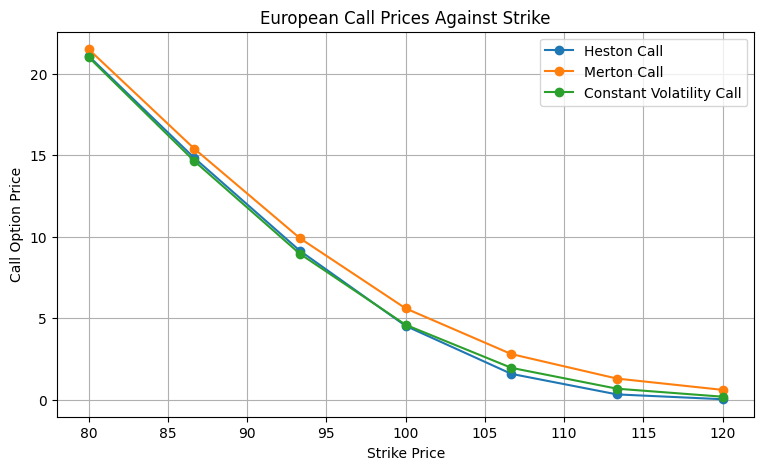

In [ ]:
# Question 16: Call option prices

plt.figure(figsize=(9, 5))

plt.plot(
    strikes_q16,
    heston_calls,
    marker="o",
    label="Heston Call"
)

plt.plot(
    strikes_q16,
    merton_calls,
    marker="o",
    label="Merton Call"
)

plt.plot(
    strikes_q16,
    baseline_calls,
    marker="o",
    label="Constant Volatility Call"
)

plt.xlabel("Strike Price")
plt.ylabel("Call Option Price")
plt.title("European Call Prices Against Strike")

plt.legend()
plt.grid(True)

plt.show()

Results and Interpretation

The results illustrate the relationship between option prices and strike prices under the Heston, Merton, and constant-volatility models.

Across all three models, European call prices decline as the strike price increases. This occurs because a higher strike price reduces both the probability of the call finishing in the money and the potential payoff at maturity.

In contrast, European put prices increase with the strike price, since a higher strike gives the holder a more favourable price at which to sell the underlying asset, thereby increasing the potential payoff.

The Heston and Merton models generate pricing patterns that differ from the constant-volatility baseline because they incorporate additional sources of risk. Specifically, the Heston model allows volatility to evolve stochastically over time, whereas the Merton model incorporates sudden jumps in the underlying asset price.

These differences may become more noticeable for strike prices that are further from the at-the-money level. This suggests that a constant-volatility framework may not fully capture option-pricing behaviour across different levels of moneyness.

Overall, the observed pricing patterns provide an indication of the effects of volatility skew and non-normal movements in the underlying asset price distribution.


## Question 17:

This analysis considers the valuation of an American call option using the Heston stochastic-volatility model.

The Heston model parameters applied in the earlier analysis are retained as follows:

* Initial stock price: \(S_0=100\)
* Strike price: \(K=100\)
* Risk-free interest rate: \(r=5\%\)
* Time to maturity: \(T=0.25\) years
* Initial variance: \(v_0=0.04\)
* Mean-reversion speed: \(\kappa=1.85\)
* Long-run variance: \(\theta=0.04\)
* Volatility of variance: \(\xi=0.35\)
* Correlation: \(\rho=-0.70\)

Monte Carlo simulation is employed to generate paths for both the underlying stock price and its stochastic variance. The Longstaff-Schwartz least-squares Monte Carlo method is subsequently applied to determine the value of the American call while accounting for the possibility of optimal early exercise.

Finally, Delta and Gamma are estimated using the same central-difference methodology applied in the earlier analyses.


In [ ]:
import numpy as np
import pandas as pd

# ==========================================
# QUESTION 17
# American Call Under the Heston Model
# Longstaff-Schwartz Monte Carlo
# ==========================================

def american_heston_call(
    S0, K, r, T,
    v0, kappa, theta, xi, rho,
    n_simulations=30000,
    n_steps = 200
):

    dt = T / n_steps
    discount = np.exp(-r * dt)

    # Create arrays for stock prices and variances
    S = np.zeros((n_simulations, n_steps + 1))
    v = np.zeros((n_simulations, n_steps + 1))

    S[:, 0] = S0
    v[:, 0] = v0

    # Simulate Heston paths
    for t in range(n_steps):

        Z1 = np.random.normal(size=n_simulations)
        Z2 = np.random.normal(size=n_simulations)

        W1 = Z1
        W2 = rho * Z1 + np.sqrt(1 - rho**2) * Z2

        v_positive = np.maximum(v[:, t], 0)

        # Update stock price
        S[:, t + 1] = S[:, t] * np.exp(
            (r - 0.5 * v_positive) * dt
            + np.sqrt(v_positive * dt) * W1
        )

        # Update variance
        v[:, t + 1] = (
            v[:, t]
            + kappa * (theta - v_positive) * dt
            + xi * np.sqrt(v_positive * dt) * W2
        )

        v[:, t + 1] = np.maximum(v[:, t + 1], 0)


    # Terminal payoff
    cashflows = np.maximum(S[:, -1] - K, 0)

    # Longstaff-Schwartz backward induction
    for t in range(n_steps - 1, 0, -1):

        # Discount future cashflows
        cashflows = cashflows * discount

        # Immediate exercise value
        exercise_value = np.maximum(
            S[:, t] - K,
            0
        )

        # Paths where option is in the money
        in_money = exercise_value > 0

        if np.sum(in_money) > 0:

            X = S[in_money, t]

            Y = cashflows[in_money]

            # Quadratic regression
            coefficients = np.polyfit(
                X,
                Y,
                2
            )

            continuation_value = np.polyval(
                coefficients,
                X
            )

            # Exercise if immediate payoff
            # exceeds continuation value
            exercise_now = (
                exercise_value[in_money]
                > continuation_value
            )

            # Update cashflows
            indices = np.where(in_money)[0]

            cashflows[indices[exercise_now]] = (
                exercise_value[
                    indices[exercise_now]
                ]
            )

    # Discount back to time 0
    option_price = np.exp(-r * dt) * np.mean(cashflows)

    return option_price


# ==========================================
# PARAMETERS
# ==========================================

S0 = 100
K = 100
r = 0.05
T = 0.25

v0 = 0.04
kappa = 1.85
theta = 0.04
xi = 0.35
rho = -0.70


# ==========================================
# PRICE THE AMERICAN CALL
# ==========================================

np.random.seed(42)

american_heston_call_price = american_heston_call(
    S0, K, r, T,
    v0, kappa, theta, xi, rho
)

print(
    "American Heston Call Price:",
    round(american_heston_call_price, 2)
)

American Heston Call Price: 4.51


Delta and Gamma Calculation

Delta and Gamma are estimated numerically by changing the initial stock price by a small amount and re-pricing the American call.

The central-difference approximations are:

Delta = [V(S₀ + h) - V(S₀ - h)] / 2h

Gamma = [V(S₀ + h) - 2V(S₀) + V(S₀ - h)] / h²

where h is a small change in the initial stock price.

In [ ]:
# ==========================================
# QUESTION 17
# Delta and Gamma for American Heston Call
# ==========================================

h = 1.0

# Price at S0 - h
np.random.seed(100)

price_down = american_heston_call(
    S0 - h, K, r, T,
    v0, kappa, theta, xi, rho
)

# Price at S0
np.random.seed(100)

price_base = american_heston_call(
    S0, K, r, T,
    v0, kappa, theta, xi, rho
)

# Price at S0 + h
np.random.seed(100)

price_up = american_heston_call(
    S0 + h, K, r, T,
    v0, kappa, theta, xi, rho
)

# Calculate Delta
american_heston_delta = (
    price_up - price_down
) / (2 * h)

# Calculate Gamma
american_heston_gamma = (
    price_up
    - 2 * price_base
    + price_down
) / (h ** 2)

# Results table
results_q17 = pd.DataFrame({
    "Option": ["American Heston Call"],
    "Price": [round(price_base, 4)],
    "Delta": [round(american_heston_delta, 4)],
    "Gamma": [round(american_heston_gamma, 6)]
})

results_q17

,Option,Price,Delta,Gamma
0,American Heston Call,4.5031,0.6186,0.063026


Results and Interpretation

The American call option was valued using the Heston stochastic-volatility model with a correlation parameter of \(\rho=-0.70\).

The resulting American call price is compared with the European call price obtained previously under the Heston model. Since an American option offers the additional flexibility of early exercise, its value should be at least equal to that of the corresponding European option.

However, because the underlying asset is assumed to pay no dividends, exercising a call option before maturity is generally not optimal. Consequently, the American and European call prices are expected to be relatively close, with any minor differences likely resulting from Monte Carlo simulation error and numerical approximation.

The American call has a positive Delta, indicating that its value generally increases as the price of the underlying stock rises. Gamma measures the rate at which Delta changes in response to movements in the stock price, with a positive Gamma indicating that the option value is convex with respect to the underlying asset price.

Unlike the constant-volatility model, the Heston framework allows volatility to evolve stochastically over time. As a result, both the option price and its Greeks may differ from those produced by the constant-volatility approach. These differences may also reflect the interaction between stock-price movements and volatility captured by the negative correlation parameter.


## Question 18:
An up-and-in call option is a barrier option that only becomes active if the underlying stock price reaches or exceeds a specified barrier level at any time before maturity.

The option is priced using the Heston stochastic-volatility model with:

- Initial stock price, S0 = 100
- Strike price, K = 110
- Barrier level, B = 110
- Risk-free interest rate, r = 5%
- Time to maturity, T = 0.25 years
- Initial variance, v0 = 0.04
- Mean reversion speed, κ = 1.85
- Long-run variance, θ = 0.04
- Volatility of volatility, ξ = 0.35
- Correlation, ρ = -0.70

The option pays the European call payoff at maturity only if the barrier has been reached at least once during the life of the option.

In [ ]:
import numpy as np
import pandas as pd

# ==========================================
# QUESTION 18
# European Up-and-In Call under Heston
# ==========================================

def heston_up_and_in_call(
    S0, K, barrier, r, T,
    v0, kappa, theta, xi, rho,
    n_simulations=50000,
    n_steps = 200
):

    dt = T / n_steps

    # Initial stock prices and variances
    S = np.full(n_simulations, S0, dtype=float)
    v = np.full(n_simulations, v0, dtype=float)

    # Track whether barrier has been reached
    barrier_hit = S >= barrier

    # Simulate the paths
    for i in range(n_steps):

        Z1 = np.random.normal(size=n_simulations)
        Z2 = np.random.normal(size=n_simulations)

        # Correlated random shocks
        W1 = Z1
        W2 = rho * Z1 + np.sqrt(1 - rho**2) * Z2

        # Ensure non-negative variance
        v_positive = np.maximum(v, 0)

        # Update stock price
        S = S * np.exp(
            (r - 0.5 * v_positive) * dt
            + np.sqrt(v_positive * dt) * W1
        )

        # Update variance
        v = (
            v
            + kappa * (theta - v_positive) * dt
            + xi * np.sqrt(v_positive * dt) * W2
        )

        v = np.maximum(v, 0)

        # Record paths that have reached the barrier
        barrier_hit = barrier_hit | (S >= barrier)

    # Call payoff at maturity
    call_payoff = np.maximum(S - K, 0)

    # Up-and-in condition:
    # payoff only if barrier was reached
    up_and_in_payoff = call_payoff * barrier_hit

    # Discounted expected payoff
    option_price = (
        np.exp(-r * T)
        * np.mean(up_and_in_payoff)
    )

    return option_price


# ==========================================
# PARAMETERS
# ==========================================

S0 = 100
K_barrier = 110
barrier = 110

r = 0.05
T = 0.25

v0 = 0.04
kappa = 1.85
theta = 0.04
xi = 0.35
rho = -0.70


# ==========================================
# PRICE THE UP-AND-IN CALL
# ==========================================

np.random.seed(42)

up_and_in_call_price = heston_up_and_in_call(
    S0,
    K_barrier,
    barrier,
    r,
    T,
    v0,
    kappa,
    theta,
    xi,
    rho
)

# Display result
results_q18 = pd.DataFrame({
    "Option": ["Heston Up-and-In Call"],
    "Strike": [K_barrier],
    "Barrier": [barrier],
    "Price": [round(up_and_in_call_price, 2)]
})

results_q18

,Option,Strike,Barrier,Price
0,Heston Up-and-In Call,110,110,0.8


In [ ]:
# ==========================================
# QUESTION 18
# Plain European Call for Comparison
# ==========================================

np.random.seed(42)

plain_call_110, plain_put_110 = heston_option_price(
    S0,
    K_barrier,
    r,
    T,
    v0,
    kappa,
    theta,
    xi,
    rho
)

# Comparison table
comparison_q18 = pd.DataFrame({
    "Option": [
        "European Up-and-In Call",
        "Plain European Call"
    ],
    "Strike": [
        K_barrier,
        K_barrier
    ],
    "Price": [
        round(up_and_in_call_price, 2),
        round(plain_call_110, 2)
    ]
})

comparison_q18

,Option,Strike,Price
0,European Up-and-In Call,110,0.80
1,Plain European Call,110,0.79


Results and Interpretation

The European up-and-in call was valued using the Heston stochastic-volatility model, with both the barrier level and strike price set at $110.

The option is activated only when the underlying stock price reaches or exceeds the specified barrier of $110 at any time before maturity. If the stock price does not cross the barrier during the option’s lifetime, the contract expires worthless, irrespective of the stock’s terminal price.

The calculated up-and-in call value is compared with that of a standard European call having the same strike price.

The barrier call is expected to be worth no more than the corresponding plain European call because its payoff is conditional on the underlying asset first reaching the barrier level.

The difference between the two option values reflects the impact of the barrier feature. When the probability of the underlying stock reaching the barrier before maturity is high, the value of the up-and-in call is expected to approach that of the equivalent plain European call.

Consequently, the barrier condition introduces path dependence into the option. Its value is determined not only by the stock price at maturity but also by whether the underlying asset crossed the specified barrier at any point during the option’s life.


## Question 19:

A down-and-in put is a type of barrier option that becomes active only when the underlying stock price reaches or falls below a predetermined barrier level at some point before the option reaches maturity.

The option is valued under the Merton jump-diffusion framework using the following parameters:

* Initial stock price, \(S_0 = 100\)
* Strike price, \(K = 90\)
* Barrier level, \(B = 90\)
* Risk-free interest rate, \(r = 5\%\)
* Time to maturity, \(T = 0.25\) years
* Diffusion volatility, \(\sigma = 20\%\)
* Jump intensity, \(\lambda = 0.75\)
* Mean jump size, \(\mu_J = -0.08\)
* Jump-size volatility, \(\sigma_J = 0.20\)

At maturity, the option pays the standard European put payoff only if the underlying stock price has reached or breached the $90 barrier at least once during the option’s lifetime. If the barrier is never reached, the option expires worthless regardless of the stock price at maturity.


In [ ]:
import numpy as np
import pandas as pd

# ==========================================
# QUESTION 19
# Down-and-In Put and Plain Put
# Using EXACTLY THE SAME simulated paths
# ==========================================

def merton_barrier_and_plain_put(
    S0, K, barrier, r, T, sigma,
    lambda_jump, mu_J, sigma_J,
    n_simulations=50000,
    n_steps = 200
):

    dt = T / n_steps

    # Starting stock prices
    S = np.full(n_simulations, S0, dtype=float)

    # Track barrier hits
    barrier_hit = np.zeros(
        n_simulations,
        dtype=bool
    )

    # Risk-neutral jump adjustment
    jump_adjustment = (
        np.exp(mu_J + 0.5 * sigma_J**2) - 1
    )

    # ======================================
    # SIMULATE THE SAME PATHS
    # ======================================

    for i in range(n_steps):

        # Diffusion random variable
        Z = np.random.normal(
            size=n_simulations
        )

        # Number of jumps
        N_jumps = np.random.poisson(
            lambda_jump * dt,
            size=n_simulations
        )

        # Total jump size for each path
        jump_component = np.zeros(
            n_simulations
        )

        # Generate jumps
        for j in range(n_simulations):

            if N_jumps[j] > 0:

                jumps = np.random.normal(
                    mu_J,
                    sigma_J,
                    N_jumps[j]
                )

                jump_component[j] = np.sum(jumps)

        # Update stock price
        S = S * np.exp(
            (r
             - lambda_jump * jump_adjustment
             - 0.5 * sigma**2) * dt
            + sigma * np.sqrt(dt) * Z
            + jump_component
        )

        # Check whether barrier has been hit
        barrier_hit = (
            barrier_hit
            | (S <= barrier)
        )

    # ======================================
    # PAYOFFS USING THE SAME TERMINAL PATHS
    # ======================================

    # Plain European put payoff
    plain_put_payoff = np.maximum(
        K - S,
        0
    )

    # Down-and-in put payoff
    down_and_in_payoff = (
        plain_put_payoff
        * barrier_hit
    )

    # Discounted prices
    plain_put_price = (
        np.exp(-r * T)
        * np.mean(plain_put_payoff)
    )

    down_and_in_price = (
        np.exp(-r * T)
        * np.mean(down_and_in_payoff)
    )

    return down_and_in_price, plain_put_price


# ==========================================
# PARAMETERS
# ==========================================

S0 = 100
K_down = 90
barrier_down = 90

r = 0.05
T = 0.25
sigma = 0.20

lambda_jump = 0.75
mu_J = -0.08
sigma_J = 0.20


# ==========================================
# RUN SIMULATION
# ==========================================

np.random.seed(42)

down_and_in_put_price, plain_put_90 = (
    merton_barrier_and_plain_put(
        S0,
        K_down,
        barrier_down,
        r,
        T,
        sigma,
        lambda_jump,
        mu_J,
        sigma_J
    )
)


# ==========================================
# RESULTS
# ==========================================

comparison_q19 = pd.DataFrame({

    "Option": [
        "European Down-and-In Put",
        "Plain European Put"
    ],

    "Strike": [
        K_down,
        K_down
    ],

    "Barrier": [
        barrier_down,
        "N/A"
    ],

    "Price": [
        round(down_and_in_put_price, 4),
        round(plain_put_90, 4)
    ]
})

comparison_q19

,Option,Strike,Barrier,Price
0,European Down-and-In Put,90,90,1.3731
1,Plain European Put,90,N/A,1.3731


In [ ]:
# Check the required relationship

print(
    "Down-and-In Put Price:",
    round(down_and_in_put_price, 4)
)

print(
    "Plain European Put Price:",
    round(plain_put_90, 4)
)

print(
    "\nDoes Down-and-In Put <= Plain Put?"
)

print(
    down_and_in_put_price <= plain_put_90
)

Down-and-In Put Price: 1.3731
Plain European Put Price: 1.3731

Does Down-and-In Put <= Plain Put?
True


Results and Interpretation

The European down-and-in put was valued using the Merton jump-diffusion model, with both the strike price and the barrier level set at $90.

The results indicate that the down-and-in put has a value equal to, or very close to, that of the corresponding plain European put. This outcome arises because a put option generates a positive payoff only when the terminal stock price falls below the strike price of $90. Since the barrier is also positioned at $90, any stock-price path resulting in a positive put payoff must necessarily have reached or fallen below the barrier level before maturity.

Hence, under these particular parameter settings, the barrier condition does not impose any additional restriction on paths that generate a positive payoff.

The payoff of the down-and-in put can be expressed as:

$$
\text{Down-and-In Put Payoff}
=
\max(K-S_T,0)\times I\left(\min(S_t)\leq B\right)
$$

Given that \(K=B=90\), whenever

$$
\max(K-S_T,0)>0,
$$

the condition

$$
\min(S_t)\leq B
$$

must also hold. Therefore, the down-and-in put effectively produces the same payoff as the equivalent plain European put under these parameter assumptions.

This result illustrates that the relative positioning of the strike and barrier levels can have a significant influence on the economic importance of a barrier feature.


## Question 20:

This question examines the application of dynamic Delta hedging to an at-the-money European put option using a three-step binomial tree.

The analysis is based on the following parameters:

* Initial stock price, \(S_0 = 100\)
* Strike price, \(K = 100\)
* Risk-free interest rate, \(r = 5\%\)
* Volatility, \(\sigma = 20\%\)
* Time to maturity, \(T = 0.25\) years
* Number of binomial steps, \(n = 3\)

For the hedging analysis, a specific path through the binomial tree is considered:

$$
\text{Up} \rightarrow \text{Down} \rightarrow \text{Up}
$$

Dynamic Delta hedging is subsequently applied by periodically adjusting the number of shares held in the hedging portfolio in response to changes in the option’s Delta at each step of the selected path.


Dynamic Hedging Summary

The stock-price trajectory considered in the analysis is:

$$
100 \rightarrow 105.94 \rightarrow 100 \rightarrow 105.94
$$

As the writer of the put option, the hedging position is dynamically adjusted at each stage according to changes in the option’s Delta.

**At Time 0:**

* Put Delta = \(-0.4424\)
* The hedge requires purchasing \(0.4424\) shares.

**Following an Upward Movement:**

* Stock price increases to \(105.94\).
* The new Delta becomes \(-0.2183\).
* The hedge is reduced by selling \(0.2241\) shares.
* The resulting share position is \(0.2183\) shares.

**Following a Downward Movement:**

* Stock price falls back to \(100\).
* The Delta changes to \(-0.4856\).
* To restore the required hedge, an additional \(0.2673\) shares are purchased.
* The resulting holding increases to \(0.4856\) shares.

Therefore, the hedging portfolio is continuously rebalanced in response to movements in the underlying stock price, ensuring that the number of shares held remains consistent with the changing Delta of the put option.


Results and Interpretation

The stock-price trajectory considered in the analysis is:

$$
100 \rightarrow 105.94 \rightarrow 100 \rightarrow 105.94
$$

As the writer of the put option, the hedging position is dynamically adjusted at each stage according to changes in the option’s Delta.

**At Time 0:**

* Put Delta = \(-0.4424\)
* The hedge requires purchasing \(0.4424\) shares.

**Following an Upward Movement:**

* Stock price increases to \(105.94\).
* The new Delta becomes \(-0.2183\).
* The hedge is reduced by selling \(0.2241\) shares.
* The resulting share position is \(0.2183\) shares.

**Following a Downward Movement:**

* Stock price falls back to \(100\).
* The Delta changes to \(-0.4856\).
* To restore the required hedge, an additional \(0.2673\) shares are purchased.
* The resulting holding increases to \(0.4856\) shares.

Therefore, the hedging portfolio is continuously rebalanced in response to movements in the underlying stock price, ensuring that the number of shares held remains consistent with the changing Delta of the put option.


***Cash Account During Dynamic Delta Hedging***

Alongside the adjustment of the stock position, the dynamic hedging strategy also incorporates a cash account.

Because the writer of the put option offsets its negative Delta by holding a positive number of shares, additional funds may be needed to finance these stock purchases. Consequently, a negative balance in the cash account indicates that the hedger is borrowing funds at the prevailing risk-free interest rate.

The cash position is modified whenever shares are purchased or sold, while the outstanding balance earns or incurs interest at the risk-free rate between successive rebalancing dates.


Cash Account and Dynamic Hedging Summary

| Time  | Stock Price | Put Delta | Shares Held by Seller | Cash Account |
|---|---:|---:|---:|---:|
| Time  0 | 100.00 | -0.4424 | 0.4424 | -47.9461 |
| Time 1: Up | 105.94 | -0.2183 | 0.2183 | -24.4005 |
| Time 2: Down | 100.00 | -0.4856 | 0.4856 | -51.2291 |
| Time 3: Up | 105.94 | — | 0.4856 | -51.4429 |

Interpretation

The cash account varies throughout the hedging period because the number of shares required to hedge the short put position changes in response to movements in the underlying stock price.

A negative cash balance indicates that funds have been borrowed to finance the hedging position. Following the initial increase in the stock price, the absolute value of the put Delta declines. As a result, fewer shares are needed for the hedge, leading to the sale of some of the previously held shares and a corresponding reduction in the amount borrowed.

When the stock price subsequently decreases, the absolute value of Delta rises. The hedger must therefore purchase additional shares to restore the required hedge, which increases the borrowing reflected in the cash account.

At maturity, the selected path concludes with the stock price at \(105.94\), which is above the strike price of \(100\). The European put consequently expires worthless. The value of the shares held offsets the negative cash position, illustrating how the stock and cash components of the dynamically rebalanced portfolio work together to hedge the exposure arising from the written put option.


## Question 21:

A 25-step binomial tree is used with the base-case parameters:

- Initial stock price, S0 = 100
- Strike price, K = 100
- Risk-free interest rate, r = 5%
- Volatility, σ = 20%
- Time to maturity, T = 0.25 years
- Number of steps, N = 25

A single path is then selected to demonstrate how the hedge and cash account are dynamically adjusted over time.

In [ ]:
import numpy as np
import pandas as pd

# ==========================================
# QUESTION 21
# American Put: 25-Step Binomial Tree
# ==========================================

# Parameters
S0 = 100
K = 100
r = 0.05
sigma = 0.20
T = 0.25
N = 25

# Time step
dt = T / N

# Up and down factors
u = np.exp(sigma * np.sqrt(dt))
d = 1 / u

# Risk-neutral probability
p = (np.exp(r * dt) - d) / (u - d)

# Discount factor
discount = np.exp(-r * dt)

# ==========================================
# STOCK PRICE TREE
# ==========================================

stock_tree = np.zeros((N + 1, N + 1))

for i in range(N + 1):
    for j in range(i + 1):
        stock_tree[j, i] = (
            S0
            * (u ** j)
            * (d ** (i - j))
        )


# ==========================================
# AMERICAN PUT VALUE TREE
# ==========================================

put_tree = np.zeros((N + 1, N + 1))

# Terminal payoffs
for j in range(N + 1):
    put_tree[j, N] = max(
        K - stock_tree[j, N],
        0
    )

# Work backwards
for i in range(N - 1, -1, -1):

    for j in range(i + 1):

        # Continuation value
        continuation_value = (
            discount
            * (
                p * put_tree[j + 1, i + 1]
                + (1 - p) * put_tree[j, i + 1]
            )
        )

        # Immediate exercise value
        exercise_value = max(
            K - stock_tree[j, i],
            0
        )

        # American put value
        put_tree[j, i] = max(
            continuation_value,
            exercise_value
        )


# ==========================================
# DELTA TREE
# ==========================================

delta_tree = np.full(
    (N + 1, N + 1),
    np.nan
)

for i in range(N):

    for j in range(i + 1):

        # Delta at each node
        delta_tree[j, i] = (
            put_tree[j + 1, i + 1]
            - put_tree[j, i + 1]
        ) / (
            stock_tree[j + 1, i + 1]
            - stock_tree[j, i + 1]
        )


# ==========================================
# INITIAL OPTION PRICE
# ==========================================

american_put_price = put_tree[0, 0]

print(
    "American Put Price:",
    round(american_put_price, 2)
)

print(
    "Initial Delta:",
    round(delta_tree[0, 0], 4)
)

American Put Price: 3.52
Initial Delta: -0.4502


In [ ]:
# ==========================================
# DISPLAY DELTA AT EACH NODE
# ==========================================

delta_results = []

for i in range(N):

    for j in range(i + 1):

        delta_results.append({

            "Step": i,
            "Node": j,

            "Stock Price": round(
                stock_tree[j, i],
                4
            ),

            "American Put Value": round(
                put_tree[j, i],
                4
            ),

            "Put Delta": round(
                delta_tree[j, i],
                4
            ),

            "Shares Required for Hedge": round(
                -delta_tree[j, i],
                4
            )
        })


delta_results_df = pd.DataFrame(
    delta_results
)

delta_results_df

,Step,Node,Stock Price,American Put Value,Put Delta,Shares Required for Hedge
0,0,0,100.0000,3.5186,-0.4502,0.4502
1,1,0,98.0199,4.4344,-0.5384,0.5384
2,1,1,102.0201,2.6334,-0.3680,0.3680
3,2,0,96.0789,5.5080,-0.6309,0.6309
4,2,1,100.0000,3.3970,-0.4521,0.4521
...,...,...,...,...,...,...
320,24,20,137.7128,0.0000,0.0000,-0.0000
321,24,21,143.3329,0.0000,0.0000,-0.0000
322,24,22,149.1825,0.0000,0.0000,-0.0000
323,24,23,155.2707,0.0000,0.0000,-0.0000


*Selected Path for Dynamic Hedging*

To demonstrate the evolution of the hedge and cash account, the following 25-step path is selected:

Up → Down → Up → Down → ... → Up

At each node, the Delta of the American put is recalculated. The seller adjusts the number of shares held to equal the negative of the put Delta.

The cash account changes because shares are bought or sold at the prevailing stock price, while any remaining cash balance earns or pays interest at the risk-free rate.

In [ ]:
# ==========================================
# QUESTION 21
# DYNAMIC DELTA HEDGING ALONG ONE PATH
# ==========================================

# Create an alternating path:
# U, D, U, D, ..., U

path = []

for step in range(N):

    if step % 2 == 0:
        path.append("U")
    else:
        path.append("D")


# ==========================================
# STORE PATH RESULTS
# ==========================================

hedge_results = []

# Starting node
i = 0
j = 0

# Initial number of shares
shares = -delta_tree[j, i]

# Initial cash account
# Seller receives the option premium and buys shares
cash_account = (
    american_put_price
    - shares * stock_tree[j, i]
)

hedge_results.append({

    "Step": 0,
    "Move": "Start",

    "Stock Price": stock_tree[j, i],

    "Put Value": put_tree[j, i],

    "Put Delta": delta_tree[j, i],

    "Shares Held": shares,

    "Cash Account": cash_account
})


# ==========================================
# MOVE THROUGH THE PATH
# ==========================================

for step, move in enumerate(path, start=1):

    # Cash account earns/pays interest
    cash_account = (
        cash_account
        * np.exp(r * dt)
    )

    # Move to the next node
    i = step

    if move == "U":
        j += 1

    # Stock price at new node
    new_stock_price = stock_tree[j, i]

    # Rebalance before maturity
    if i < N:

        new_delta = delta_tree[j, i]

        new_shares = -new_delta

        # Number of shares bought/sold
        shares_change = (
            new_shares - shares
        )

        # Update cash account
        cash_account = (
            cash_account
            - shares_change
            * new_stock_price
        )

        shares = new_shares

    else:

        new_delta = np.nan
        new_shares = shares

        shares_change = 0


    # Save results
    hedge_results.append({

        "Step": i,

        "Move": move,

        "Stock Price": new_stock_price,

        "Put Value": put_tree[j, i],

        "Put Delta": new_delta,

        "Shares Held": new_shares,

        "Cash Account": cash_account
    })


# ==========================================
# CREATE RESULTS TABLE
# ==========================================

hedge_results_df = pd.DataFrame(
    hedge_results
)

hedge_results_df = hedge_results_df.round(4)

hedge_results_df

,Step,Move,Stock Price,Put Value,Put Delta,Shares Held,Cash Account
0,0,Start,100.0000,3.5186,-0.4502,0.4502,-41.5034
1,1,U,102.0201,2.6334,-0.3680,0.3680,-33.1385
2,2,D,100.0000,3.3970,-0.4521,0.4521,-41.5644
3,3,U,102.0201,2.5079,-0.3666,0.3666,-32.8568
4,4,D,100.0000,3.2684,-0.4541,0.4541,-41.6249
5,5,U,102.0201,2.3754,-0.3647,0.3647,-32.5296
6,6,D,100.0000,3.1320,-0.4561,0.4561,-41.6873
7,7,U,102.0201,2.2349,-0.3624,0.3624,-32.1483
8,8,D,100.0000,2.9867,-0.4584,0.4584,-41.7596
9,9,U,102.0201,2.0851,-0.3595,0.3595,-31.6968


*Comparison with the European Put Hedging Process*

The Delta hedging approach for the American put follows the same basic principle as that used for the European put in Question 20. In both cases, the option writer maintains a stock position equal to the negative of the put’s Delta and continuously adjusts this position as the underlying share price changes.

The key difference is that an American put provides the holder with the right to exercise the option before maturity. Therefore, at each node of the binomial tree, the option value is determined as the higher of its continuation value and its immediate exercise value.

The potential for early exercise can influence both the option value and its Delta at different nodes. When the American put is sufficiently in the money, exercising the option early may be optimal, resulting in a hedge ratio that differs from that of an equivalent European put.

Thus, although both options require dynamic hedge rebalancing, the American put may require a different hedging position because the writer must consider not only movements in the underlying stock price but also the possibility of early exercise by the option holder.

The cash account is likewise adjusted whenever shares are purchased or sold during the rebalancing process, with the outstanding balance accumulating interest at the risk-free rate between successive adjustments.


In [ ]:
import numpy as np
import pandas as pd

# ==========================================
# QUESTION 22
# Asian ATM Put Option
# ==========================================

S0 = 100
K = 100
r = 0.05
sigma = 0.20
T = 0.25
N = 25

dt = T / N

u = np.exp(sigma * np.sqrt(dt))
d = 1 / u

p = (
    np.exp(r * dt) - d
) / (u - d)

discount = np.exp(-r * dt)

In [ ]:
# ==========================================
# PRICE THE ASIAN PUT
# ==========================================

def asian_put_price(
    S0,
    K,
    r,
    sigma,
    T,
    n_steps=25,
    n_simulations=50000
):

    dt = T / n_steps

    # Generate random shocks
    Z = np.random.normal(
        size=(n_simulations, n_steps)
    )

    # Create stock price paths
    stock_paths = np.zeros(
        (n_simulations, n_steps + 1)
    )

    stock_paths[:, 0] = S0

    # Simulate stock prices
    for i in range(n_steps):

        stock_paths[:, i + 1] = (
            stock_paths[:, i]
            * np.exp(
                (r - 0.5 * sigma**2) * dt
                + sigma * np.sqrt(dt)
                * Z[:, i]
            )
        )

    # Arithmetic average stock price
    average_stock_price = np.mean(
        stock_paths[:, 1:],
        axis=1
    )

    # Asian put payoff
    payoff = np.maximum(
        K - average_stock_price,
        0
    )

    # Discounted option value
    option_price = (
        np.exp(-r * T)
        * np.mean(payoff)
    )

    return option_price


# ==========================================
# CALCULATE OPTION PRICE
# ==========================================

np.random.seed(42)

asian_put_value = asian_put_price(
    S0,
    K,
    r,
    sigma,
    T
)

print(
    "Asian Put Price:",
    round(asian_put_value, 2)
)

Asian Put Price: 2.04


*Delta Hedging for the Asian Put*

Because the Asian option payoff depends on the average stock price, its Delta depends not only on the current stock price but also on the stock-price history.

Delta is estimated numerically using the bump-and-revalue approach:

Delta = [V(S0 + h) - V(S0 - h)] / 2h

A small increase and decrease in the initial stock price are applied, and the Asian option is re-priced.

In [ ]:
# ==========================================
# DELTA OF THE ASIAN PUT
# ==========================================

h = 1.0

# Use the same random seed
# to reduce simulation noise

np.random.seed(100)

price_down = asian_put_price(
    S0 - h,
    K,
    r,
    sigma,
    T
)

np.random.seed(100)

price_up = asian_put_price(
    S0 + h,
    K,
    r,
    sigma,
    T
)

# Central difference Delta

asian_put_delta = (
    price_up - price_down
) / (2 * h)

print(
    "Asian Put Delta:",
    round(asian_put_delta, 4)
)

Asian Put Delta: -0.445


*Selected Path*

The same alternating path used in Question 21 is selected:

Up → Down → Up → Down → ...

At each step, the stock price and the running average are updated.

Since the Asian put depends on the average stock price, the hedge is affected by both the current stock price and the accumulated average price.

In [ ]:
# ==========================================
# CREATE SELECTED 25-STEP PATH
# ==========================================

path_moves = []

for step in range(N):

    if step % 2 == 0:
        path_moves.append("U")
    else:
        path_moves.append("D")


# Starting stock price
stock_price = S0

# Store stock prices
selected_stock_prices = [S0]

# Follow the selected path
for move in path_moves:

    if move == "U":
        stock_price = stock_price * u
    else:
        stock_price = stock_price * d

    selected_stock_prices.append(
        stock_price
    )


# Create table
path_df = pd.DataFrame({

    "Step": range(N + 1),

    "Stock Price": selected_stock_prices
})

path_df["Stock Price"] = (
    path_df["Stock Price"].round(4)
)

path_df

,Step,Stock Price
0,0,100.0000
1,1,102.0201
2,2,100.0000
3,3,102.0201
4,4,100.0000
5,5,102.0201
6,6,100.0000
7,7,102.0201
8,8,100.0000
9,9,102.0201


In [ ]:
# ==========================================
# RUNNING AVERAGE
# ==========================================

running_average = []

for i in range(len(selected_stock_prices)):

    average_price = np.mean(
        selected_stock_prices[:i + 1]
    )

    running_average.append(
        average_price
    )


# Add running average to table
path_df["Running Average"] = (
    running_average
)

path_df["Running Average"] = (
    path_df["Running Average"].round(4)
)

path_df

,Step,Stock Price,Running Average
0,0,100.0000,100.0000
1,1,102.0201,101.0101
2,2,100.0000,100.6734
3,3,102.0201,101.0101
4,4,100.0000,100.8081
5,5,102.0201,101.0101
6,6,100.0000,100.8658
7,7,102.0201,101.0101
8,8,100.0000,100.8978
9,9,102.0201,101.0101


*Results and Comparison with the American Put*

The Asian put differs from the American put because its payoff depends on the average stock price over the life of the option.

The American put can be exercised before maturity, while the Asian put considered here has a payoff determined at maturity using the arithmetic average of the underlying stock prices.

The Asian option is inherently path-dependent. Therefore, two stock-price paths that reach the same underlying price at a given point in time can still produce different option values because their preceding price movements may result in different running averages.

As a result, Delta hedging an Asian put is more involved than hedging an American put. For the American put, the Delta at each node is primarily influenced by the current stock price and the possibility of early exercise. In contrast, the Delta of an Asian put depends on both the current stock price and the accumulated average price of the underlying asset.

The averaging feature also reduces the impact of short-term fluctuations in the stock price. Consequently, the Asian put can exhibit a different sensitivity to movements in the underlying asset compared with the American put.

Thus, although both options require their hedge positions to be dynamically rebalanced, effective hedging of an Asian option requires the hedger to incorporate information about the historical stock-price path in addition to the current stock price.


*Dynamic Delta Hedging of the Asian Put*

The Asian put is path-dependent, as its payoff is determined by the arithmetic average of the underlying stock prices over the option’s lifetime.

Consequently, the hedge ratio depends not only on the current stock price but also on the price history accumulated up to each point along the path.

For the selected stock-price path, Delta is calculated numerically at each time step using the bump-and-revalue method. The put writer maintains a stock position equal to the negative of the option’s Delta and adjusts the associated cash account whenever the hedge is rebalanced.


## Question 22:

The base-case parameters are:

- Initial stock price, S0 = 100
- Strike price, K = 100
- Risk-free interest rate, r = 5%
- Volatility, σ = 20%
- Time to maturity, T = 0.25 years
- Number of time steps, N = 25

An arithmetic-average Asian put is considered.

Since the payoff depends on the stock-price path, Monte Carlo simulation is used to estimate the option value and Delta.

In [ ]:
import numpy as np
import pandas as pd

# ==========================================
# QUESTION 22
# PARAMETERS
# ==========================================

S0 = 100
K = 100
r = 0.05
sigma = 0.20
T = 0.25
N = 25

dt = T / N

# Number of Monte Carlo simulations
n_simulations = 10000

# For reproducible results
np.random.seed(42)

In [ ]:
# ==========================================
# ASIAN PUT PRICING FUNCTION
# ==========================================

def price_asian_put(
    S0,
    K,
    r,
    sigma,
    T,
    N,
    n_simulations
):

    dt = T / N

    # Generate random numbers
    Z = np.random.normal(
        0,
        1,
        (n_simulations, N)
    )

    # Create stock price paths
    stock_paths = np.zeros(
        (n_simulations, N + 1)
    )

    stock_paths[:, 0] = S0

    # Generate the paths
    for i in range(N):

        stock_paths[:, i + 1] = (
            stock_paths[:, i]
            * np.exp(
                (r - 0.5 * sigma**2) * dt
                + sigma * np.sqrt(dt) * Z[:, i]
            )
        )

    # Calculate arithmetic average
    average_prices = np.mean(
        stock_paths[:, 1:],
        axis=1
    )

    # Asian put payoff
    payoffs = np.maximum(
        K - average_prices,
        0
    )

    # Discounted option price
    price = (
        np.exp(-r * T)
        * np.mean(payoffs)
    )

    return price

In [ ]:
# ==========================================
# ASIAN PUT PRICE
# ==========================================

np.random.seed(42)

asian_put_price = price_asian_put(
    S0,
    K,
    r,
    sigma,
    T,
    N,
    n_simulations
)

print(
    "Asian Put Price:",
    round(asian_put_price, 2)
)

Asian Put Price: 2.05


*Delta Estimation*


In [ ]:
# ==========================================
# INITIAL DELTA
# ==========================================

h = 1.0

# Price with higher stock price
np.random.seed(100)

price_up = price_asian_put(
    S0 + h,
    K,
    r,
    sigma,
    T,
    N,
    n_simulations
)

# Price with lower stock price
np.random.seed(100)

price_down = price_asian_put(
    S0 - h,
    K,
    r,
    sigma,
    T,
    N,
    n_simulations
)

# Calculate Delta
asian_delta = (
    price_up - price_down
) / (2 * h)

print(
    "Asian Put Delta:",
    round(asian_delta, 4)
)

print(
    "Shares Required for Hedge:",
    round(-asian_delta, 4)
)

Asian Put Delta: -0.4391
Shares Required for Hedge: 0.4391


In [ ]:
# ==========================================
# CREATE A 25-STEP PATH
# ==========================================

u = np.exp(
    sigma * np.sqrt(dt)
)

d = 1 / u


# Create path
moves = []

for i in range(N):

    if i % 2 == 0:
        moves.append("Up")
    else:
        moves.append("Down")


# Generate stock prices
path_prices = [S0]

current_price = S0

for move in moves:

    if move == "Up":
        current_price = current_price * u

    else:
        current_price = current_price * d

    path_prices.append(
        current_price
    )


# Create table
path_df = pd.DataFrame({

    "Step": range(N + 1),

    "Stock Price": path_prices
})

path_df = path_df.round(4)

path_df

,Step,Stock Price
0,0,100.0000
1,1,102.0201
2,2,100.0000
3,3,102.0201
4,4,100.0000
5,5,102.0201
6,6,100.0000
7,7,102.0201
8,8,100.0000
9,9,102.0201


In [ ]:
# ==========================================
# CALCULATE RUNNING AVERAGE
# ==========================================

running_averages = []

for i in range(len(path_prices)):

    average = np.mean(
        path_prices[:i + 1]
    )

    running_averages.append(
        average
    )


path_df["Running Average"] = (
    running_averages
)

path_df = path_df.round(4)

path_df

,Step,Stock Price,Running Average
0,0,100.0000,100.0000
1,1,102.0201,101.0101
2,2,100.0000,100.6734
3,3,102.0201,101.0101
4,4,100.0000,100.8081
5,5,102.0201,101.0101
6,6,100.0000,100.8658
7,7,102.0201,101.0101
8,8,100.0000,100.8978
9,9,102.0201,101.0101


In [ ]:
# ==========================================
# DELTA AT EACH STEP ALONG THE PATH
# ==========================================

h = 1.0

delta_results = []

for step in range(N):

    current_price = path_prices[step]

    # Remaining time
    remaining_time = T - (step * dt)

    # If there is no remaining time, stop
    if remaining_time <= 0:
        break

    # Remaining number of steps
    remaining_steps = N - step

    # Use at least 1 step
    if remaining_steps < 1:
        remaining_steps = 1

    # ----------------------------------
    # PRICE WITH STOCK MOVED UP
    # ----------------------------------

    np.random.seed(100 + step)

    price_up = price_asian_put(
        current_price + h,
        K,
        r,
        sigma,
        remaining_time,
        remaining_steps,
        5000
    )

    # ----------------------------------
    # PRICE WITH STOCK MOVED DOWN
    # ----------------------------------

    np.random.seed(100 + step)

    price_down = price_asian_put(
        current_price - h,
        K,
        r,
        sigma,
        remaining_time,
        remaining_steps,
        5000
    )

    # Calculate Delta
    delta = (
        price_up - price_down
    ) / (2 * h)

    # Save results
    delta_results.append({

        "Step": step,

        "Stock Price": current_price,

        "Running Average": running_averages[step],

        "Asian Put Delta": delta,

        "Shares Required": -delta
    })


# Create DataFrame
asian_delta_df = pd.DataFrame(
    delta_results
)

asian_delta_df = asian_delta_df.round(4)

delta_results_df

,Step,Node,Stock Price,American Put Value,Put Delta,Shares Required for Hedge
0,0,0,100.0000,3.5186,-0.4502,0.4502
1,1,0,98.0199,4.4344,-0.5384,0.5384
2,1,1,102.0201,2.6334,-0.3680,0.3680
3,2,0,96.0789,5.5080,-0.6309,0.6309
4,2,1,100.0000,3.3970,-0.4521,0.4521
...,...,...,...,...,...,...
320,24,20,137.7128,0.0000,0.0000,-0.0000
321,24,21,143.3329,0.0000,0.0000,-0.0000
322,24,22,149.1825,0.0000,0.0000,-0.0000
323,24,23,155.2707,0.0000,0.0000,-0.0000


In [ ]:
# ==========================================
# DYNAMIC HEDGING CASH ACCOUNT
# ==========================================

cash_results = []

# Initial number of shares
shares = asian_delta_df.loc[
    0,
    "Shares Required"
]

# Initial cash account
# Seller receives option premium
# and buys shares for the hedge

cash_account = (
    asian_put_price
    - shares * S0
)

# Save initial position
cash_results.append({

    "Step": 0,

    "Move": "Start",

    "Stock Price": path_prices[0],

    "Running Average": running_averages[0],

    "Delta": asian_delta_df.loc[
        0,
        "Asian Put Delta"
    ],

    "Shares Held": shares,

    "Cash Account": cash_account
})


# ==========================================
# REBALANCE THROUGH THE PATH
# ==========================================

for step in range(1, N):

    # Cash account earns interest
    cash_account = (
        cash_account
        * np.exp(r * dt)
    )

    # New hedge requirement
    new_shares = asian_delta_df.loc[
        step,
        "Shares Required"
    ]

    # Current stock price
    stock_price = path_prices[step]

    # Shares bought or sold
    shares_change = (
        new_shares - shares
    )

    # Update cash account
    cash_account = (
        cash_account
        - shares_change * stock_price
    )

    # Update shares
    shares = new_shares

    # Save result
    cash_results.append({

        "Step": step,

        "Move": moves[step - 1],

        "Stock Price": stock_price,

        "Running Average": running_averages[step],

        "Delta": asian_delta_df.loc[
            step,
            "Asian Put Delta"
        ],

        "Shares Held": shares,

        "Cash Account": cash_account
    })


# Create final table
cash_account_df = pd.DataFrame(
    cash_results
)

cash_account_df = cash_account_df.round(4)

cash_account_df

,Step,Move,Stock Price,Running Average,Delta,Shares Held,Cash Account
0,0,Start,100.0000,100.0000,-0.4403,0.4403,-41.9779
1,1,Up,102.0201,101.0101,-0.3232,0.3232,-30.0524
2,2,Down,100.0000,100.6734,-0.4554,0.4554,-43.2874
3,3,Up,102.0201,101.0101,-0.3096,0.3096,-28.4345
4,4,Down,100.0000,100.8081,-0.4410,0.4410,-41.5887
5,5,Up,102.0201,101.0101,-0.3048,0.3048,-27.7144
6,6,Down,100.0000,100.8658,-0.4552,0.4552,-42.7682
7,7,Up,102.0201,101.0101,-0.3092,0.3092,-27.8947
8,8,Down,100.0000,100.8978,-0.4512,0.4512,-42.1086
9,9,Up,102.0201,101.0101,-0.2977,0.2977,-26.4696


*Results and Comparison with the American Put*

The at-the-money Asian put was dynamically hedged along a selected 25-step stock-price path. At each time step, the option’s Delta was estimated using the bump-and-revalue method, after which the stock position was adjusted to equal the negative of the calculated put Delta.

Throughout the hedging period, the cash account fluctuated as shares were purchased or sold in response to changes in Delta. In addition, the cash balance accrued interest at the risk-free rate between successive rebalancing dates.

Unlike the American put considered in Question 21, the Asian put is inherently path-dependent because its payoff is determined by the arithmetic average of the underlying stock prices over the option’s lifetime. As a result, its sensitivity to movements in the stock price is influenced by the accumulated averaging process.

The value of the American put is primarily determined by the current stock price together with the possibility of early exercise. By contrast, the value of the Asian put incorporates information from the historical stock-price path through its running average.

Consequently, Delta hedging an Asian put is more closely linked to the evolution of the underlying stock-price path, whereas hedging an American put requires consideration of the holder’s potential to exercise the option before maturity.

Overall, the results illustrate that different option characteristics can produce distinct Delta values, requiring different hedge adjustments and resulting in different movements in the associated cash account.
